In [1]:
rm(list = ls())

library(httr);library(jsonlite);library(dplyr);library(ggplot2);library(readxl); #library(patchwork);
library(readxl);library(raster);library(lubridate);library(RNetCDF); #library(ggpmisc);
library(ncdf4);library(dplyr);library(tidyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: sp


Attaching package: ‘raster’


The following object is masked from ‘package:dplyr’:

    select



Attaching package: ‘lubridate’


The following objects are masked from ‘package:raster’:

    intersect, union


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Attaching package: ‘tidyr’


The following object is masked from ‘package:raster’:

    extract




In [2]:
# ------------------------------ READING IN AND CLEANING DATA -------------------------------------
# Read in observational data (excel file) with specified parameters -----------------------
data.file <- "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/24.10.16_FeObs_Hamilton2022_updated2024_Tang.xlsx"

obs.data <- read_excel(data.file, sheet = "Tang_approved_comparisons", 
                       col_names = TRUE,
                       na = c("-99", "-9999", "-99.0","-0.99", "NA"))

# function convert any longitude encoded as deg W to 360 E 
convert_longitude <- function(longitude) { #check integer vs real numbers to ensure nothing was rounded weird 
  if (longitude < 0.0) {
    return(360.0 + longitude)
  } else {
    return(longitude)
  }
}

# Convert Longitude column
obs.data$Longitude <- sapply(obs.data$Longitude, convert_longitude)

# Read in the simulations data (netcdf files) ----------------------------------------------
# when multiple timepoints still exist -- find averages and standard deviations over time
generate_median_values_from_netcdf <- function(file_directory, var1_name, var2_name) {
  # Open the NetCDF file
  nc_data <- nc_open(file_directory)
  
  # Extract latitude and longitude options
  all_long_options <- ncvar_get(nc_data, "lon")
  all_lat_options <- ncvar_get(nc_data, "lat")
  
  # Round latitude to 3 decimal places to match the PD files 
  all_lat_options <- round(all_lat_options, 3)
  
  # Extract the specified variables
  variable1 <- ncvar_get(nc_data, var1_name)
  variable2 <- ncvar_get(nc_data, var2_name)
  
  # Calculate mean values for the specified variables
  mean_var1 <- apply(variable1, c(1, 2), median, na.rm = TRUE)
  mean_var2 <- apply(variable2, c(1, 2), median, na.rm = TRUE)
  
  # Calculate mean values for the specified variables
  sd_var1 <- apply(variable1, c(1, 2), sd, na.rm = TRUE)
  sd_var2 <- apply(variable2, c(1, 2), sd, na.rm = TRUE)
  
  # Close the NetCDF file
  nc_close(nc_data)
  
  # Convert results to data frames with latitude and longitude columns
  mean_var1_df <- data.frame(
    latitude = rep(all_lat_options, each = length(all_long_options)),
    longitude = rep(all_long_options, length(all_lat_options)),
    mean_value = as.vector(mean_var1)
  )
  
  mean_var2_df <- data.frame(
    latitude = rep(all_lat_options, each = length(all_long_options)),
    longitude = rep(all_long_options, length(all_lat_options)),
    mean_value = as.vector(mean_var2)
  )
  
  sd_var1_df <- data.frame(
    latitude = rep(all_lat_options, each = length(all_long_options)),
    longitude = rep(all_long_options, length(all_lat_options)),
    sd_value = as.vector(sd_var1)
  )
  
  sd_var2_df <- data.frame(
    latitude = rep(all_lat_options, each = length(all_long_options)),
    longitude = rep(all_long_options, length(all_lat_options)),
    sd_value = as.vector(sd_var2)
  )
  
  # Reshape data frames to wide format
  coords_wide_var1 <- pivot_wider(mean_var1_df, names_from = longitude, values_from = mean_value)
  coords_wide_var2 <- pivot_wider(mean_var2_df, names_from = longitude, values_from = mean_value)
  
  # Reshape sd data frames to wide format
  coords_wide_var1_sd <- pivot_wider(sd_var1_df, names_from = longitude, values_from = sd_value)
  coords_wide_var2_sd <- pivot_wider(sd_var2_df, names_from = longitude, values_from = sd_value)
  
  # Convert tibbles to data frames and set row names
  coords_wide_var1 <- as.data.frame(coords_wide_var1)
  coords_wide_var2 <- as.data.frame(coords_wide_var2)
  rownames(coords_wide_var1) <- all_lat_options
  rownames(coords_wide_var2) <- all_lat_options
  coords_wide_var1 <- coords_wide_var1 %>% dplyr::select(-latitude)
  coords_wide_var2 <- coords_wide_var2 %>% dplyr::select(-latitude)
  
  coords_wide_var1_sd <- as.data.frame(coords_wide_var1_sd)
  coords_wide_var2_sd <- as.data.frame(coords_wide_var2_sd)
  rownames(coords_wide_var1_sd) <- all_lat_options
  rownames(coords_wide_var2_sd) <- all_lat_options
  coords_wide_var1_sd <- coords_wide_var1_sd %>% dplyr::select(-latitude)
  coords_wide_var2_sd <- coords_wide_var2_sd %>% dplyr::select(-latitude)
  
  # Return the wide data frames
  list(coords_wide_var1, coords_wide_var2, coords_wide_var1_sd, coords_wide_var2_sd)
}

# when data is already a mean 
read_in_netcdf <- function(file_directory, var1_name, var2_name) {
  # Open the NetCDF file
  nc_data <- nc_open(file_directory)
  
  # Extract latitude and longitude options
  all_long_options <- ncvar_get(nc_data, "lon")
  all_lat_options <- ncvar_get(nc_data, "lat")
  
  # Extract the specified variables
  variable1 <- ncvar_get(nc_data, var1_name)
  variable2 <- ncvar_get(nc_data, var2_name)
   
  # Close the NetCDF file
  nc_close(nc_data)
  
  # Convert results to data frames with latitude and longitude columns
  mean_var1_df <- data.frame(
    latitude = rep(all_lat_options, each = length(all_long_options)),
    longitude = rep(all_long_options, length(all_lat_options)),
    mean_value = as.vector(variable1)
  )
  
  mean_var2_df <- data.frame(
    latitude = rep(all_lat_options, each = length(all_long_options)),
    longitude = rep(all_long_options, length(all_lat_options)),
    mean_value = as.vector(variable2)
  )
  
  # Reshape data frames to wide format
  coords_wide_var1 <- pivot_wider(mean_var1_df, names_from = longitude, values_from = mean_value)
  coords_wide_var2 <- pivot_wider(mean_var2_df, names_from = longitude, values_from = mean_value)
  
  # Convert tibbles to data frames and set row names
  coords_wide_var1 <- as.data.frame(coords_wide_var1)
  coords_wide_var2 <- as.data.frame(coords_wide_var2)
  rownames(coords_wide_var1) <- all_lat_options
  rownames(coords_wide_var2) <- all_lat_options
  coords_wide_var1 <- coords_wide_var1 %>% dplyr::select(-latitude)
  coords_wide_var2 <- coords_wide_var2 %>% dplyr::select(-latitude)
  
  # Return the wide data frames
  list(coords_wide_var1, coords_wide_var2)
}

print("done") 

[1] "done"


In [14]:
# PD SIMULATIONS -----------------------------------------------------
# this should take ~ 400 seconds
# v1 (PD) INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38-FINEFIRE33 ORIGINAL <- as of 4/2026 fixed dust in the HIGH file
result <- generate_median_values_from_netcdf("/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/output_files/MEDFEFRAC_reruns/CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38.cam.h2_HIGH.nc", 
                                             "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("nobackup/JupyterLinks/notebooks/cesm_files/output_files/\
#CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38.cam.h2_DUSTx3.8.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38.cam.h2.nc", "FETOTSRF", "FESOLSRF")
coords_wide.med.v1 <- result[[1]]
coords_wide.sol.med.v1 <- result[[2]]
coords_wide.med.v1_sd <- result[[3]]
coords_wide.sol.med.v1_sd <- result[[4]]

# v2 (PD) INDCOAL0.2-RESICOAL33-WOOD10-OIL38 ORIGINAL # <- as of 4/2026 fixed dust in the HIGH file
result <- generate_median_values_from_netcdf("/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/output_files/MEDFEFRAC_reruns/CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD10-OIL38.cam.h2_HIGH.nc", 
                                             "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("nobackup/JupyterLinks/notebooks/cesm_files/output_files/\
#CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD10-OIL38.cam.h2_DUSTx3.8.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD10-OIL38.cam.h2.nc", "FETOTSRF", "FESOLSRF")
coords_wide.med.v2 <- result[[1]]
coords_wide.sol.med.v2 <- result[[2]]
coords_wide.med.v2_sd <- result[[3]]
coords_wide.sol.med.v2_sd <- result[[4]]

# v3 (PD) INDCOAL0.2-RESICOAL33-WOOD56-OIL38 ORIGINAL # <- as of 4/2026 fixed dust in the HIGH file
# recall labels flipped with v2 -- this was true for Cheyenne, not sure if this is true for Derecho version check in on this later  
result <- generate_median_values_from_netcdf("/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/output_files/MEDFEFRAC_reruns/CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD56-OIL38.cam.h2_HIGH.nc", 
                                             "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("nobackup/JupyterLinks/notebooks/cesm_files/output_files/\
#CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD56-OIL38.cam.h2_DUSTx3.8.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD56-OIL38.cam.h2.nc", "FETOTSRF", "FESOLSRF")
coords_wide.med.v3 <- result[[1]]
coords_wide.sol.med.v3 <- result[[2]]
coords_wide.med.v3_sd <- result[[3]]
coords_wide.sol.med.v3_sd <- result[[4]]

# v4 (PD) INDCOAL0.05-RESICOAL33-WOOD56-OIL25 PD-IND-HIGH MAKE SURE THIS DUST IS RIGHT BEFORE PLOTTING <- h1 file suggests NO -- scale by 3.8  
result <- generate_median_values_from_netcdf("/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/output_files/MEDFEFRAC_reruns/DUST_FIX/CAM6-MIMI_2010CLIMO_INDCOAL0.05-RESICOAL33-WOOD56-OIL25.cam.h2.2009-2011_PD_import_DUST.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38_scale_BF.cam.h2.2009-2011_filtered_DUSTx3.8.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38_scale_BF.cam.h2.2009-2011_filtered.nc", "FETOTSRF", "FESOLSRF")
coords_wide.med.v4 <- result[[1]]
coords_wide.sol.med.v4 <- result[[2]]
coords_wide.med.v4_sd <- result[[3]]
coords_wide.sol.med.v4_sd <- result[[4]]

# CENTRAL LOW INVENTORIES --------------------------------------------------------------------------------
# v5 (PD) INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38 NEW INVENTORY
result <- generate_median_values_from_netcdf("/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/output_files/MEDFEFRAC_reruns/DUST_FIX/CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38-WASTE1.5_MEDFEFRAC_DUSTFETUNED.cam.h2.2009-2011_import_DUST.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38_scale_BF.cam.h2.2009-2011_filtered_DUSTx3.8.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38_scale_BF.cam.h2.2009-2011_filtered.nc", "FETOTSRF", "FESOLSRF")
coords_wide.med.v5 <- result[[1]]
coords_wide.sol.med.v5 <- result[[2]]
coords_wide.med.v5_sd <- result[[3]]
coords_wide.sol.med.v5_sd <- result[[4]]

# v6 (PD) INDCOAL0.2-RESICOAL33-WOOD10-OIL38 NEW INVENTORY
result <- generate_median_values_from_netcdf("/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/output_files/MEDFEFRAC_reruns/DUST_FIX/CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD10-OIL38-WASTE1.5_MEDFEFRAC_DUSTFETUNED.cam.h2.2009-2011_import_DUST.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD10-OIL38_scale_BF.cam.h2.2009-2011_DUSTx3.8.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD10-OIL38_scale_BF.cam.h2.2009-2011.nc", "FETOTSRF", "FESOLSRF")
coords_wide.med.v6 <- result[[1]]
coords_wide.sol.med.v6 <- result[[2]]
coords_wide.med.v6_sd <- result[[3]]
coords_wide.sol.med.v6_sd <- result[[4]]

# v7 (PD) INDCOAL0.2-RESICOAL33-WOOD56-OIL38 NEW INVENTORY
result <- generate_median_values_from_netcdf("/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/output_files/MEDFEFRAC_reruns/DUST_FIX/CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD56-OIL38-WASTE1.5_MEDFEFRAC_DUSTFETUNED.cam.h2.2009-2011_import_DUST.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD56-OIL38_scale_BF.cam.h2.2009-2011_filtered_DUSTx3.8.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD56-OIL38_scale_BF.cam.h2.2009-2011_filtered.nc", "FETOTSRF", "FESOLSRF")
coords_wide.med.v7 <- result[[1]]
coords_wide.sol.med.v7 <- result[[2]]
coords_wide.med.v7_sd <- result[[3]]
coords_wide.sol.med.v7_sd <- result[[4]]

# v8 (PD) INDCOAL0.05-RESICOAL33-WOOD56-OIL25 NEW INVENTORY
result <- generate_median_values_from_netcdf("/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/output_files/MEDFEFRAC_reruns/DUST_FIX/CAM6-MIMI_2010CLIMO_INDCOAL0.05-RESICOAL33-WOOD56-OIL25-WASTE1.5_MEDFEFRAC_DUSTFETUNED.cam.h2.2009-2011_import_DUST.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD56-OIL38_scale_BF.cam.h2.2009-2011_filtered_DUSTx3.8.nc", "FETOTSRF", "FESOLSRF")
#result <- generate_median_values_from_netcdf("CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD56-OIL38_scale_BF.cam.h2.2009-2011_filtered.nc", "FETOTSRF", "FESOLSRF")
coords_wide.med.v8 <- result[[1]]
coords_wide.sol.med.v8 <- result[[2]]
coords_wide.med.v8_sd <- result[[3]]
coords_wide.sol.med.v8_sd <- result[[4]]

print("done") 

[1] "done"


In [15]:
# get dimensions of netcdf files to store for later ----------------------------------------
dim.file <- "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/output_files/CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38_scale_BF.cam.h2.2009-2011_filtered.nc"
nc_data <- nc_open(dim.file)
# Extract latitude and longitude options
all_lon_options <- ncvar_get(nc_data, "lon")
all_lat_options <- ncvar_get(nc_data, "lat")
all_lat_options <- round(all_lat_options, 3)
nc_close(nc_data)

# Simplifying matching of observational to modeled data
library(purrr)

# INDIVIDUAL COMPARISONS OBS TO MOD -- stick to medians when aggregating
obs.data.ind <- obs.data %>% dplyr::select(-Month) %>%
  mutate(Model_Latitude_Values = map_dbl(Latitude, ~ all_lat_options[which.min(abs(all_lat_options - .x))])) 
obs.data.mod.res <- obs.data.ind %>%
  mutate(Model_Longitude_Values = map_dbl(Longitude, ~ all_lon_options[which.min(abs(all_lon_options - .x))]))

obs.data.mod.res.ind <- obs.data.mod.res %>%
  mutate(`Fe (ng m–3)_median` = `Fe (ng m–3)`,
         `Fe (ng m–3)_sd` = 0, 
         `labile Fe (ng m–3)_median` = `labile Fe (ng m–3)`,
         `labile Fe (ng m–3)_sd` = 0,
         `Fe solubility_median` = `Fe solubility`,
         `Fe solubility_sd` = 0) %>%
  dplyr::select(Model_Latitude_Values, Model_Longitude_Values, `Fe (ng m–3)_median`, `Fe (ng m–3)_sd`, 
                `labile Fe (ng m–3)_median`, `labile Fe (ng m–3)_sd`, `Fe solubility_median`, `Fe solubility_sd`) %>%
  rename_with(~ paste0(.x, "_ind"), 
              .cols = !c("Model_Latitude_Values", "Model_Longitude_Values"))

# n1 AGGREGATED BY GRID CELL (1x1)
obs.data.mod.res.n1 <- obs.data.mod.res %>%
    mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>%
    group_by(Model_Latitude_Values, Model_Longitude_Values) %>%
    summarise(across(c("Fe (ng m–3)", "Fe solubility", "labile Fe (ng m–3)"), 
                     list(median = median, sd = sd), na.rm = TRUE), .groups = 'drop') %>%
    ungroup() 

# combine observational with modeled data ----------------------------------
library(tibble)    
# v1 ------
coords_long.med.v1_median <- coords_wide.med.v1 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>%
rename(v1_Fe = value)

coords_long.med.v1_sd <- coords_wide.med.v1_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v1_Fe_sd = value)

coords_long.med.v1 <- full_join(coords_long.med.v1_median, coords_long.med.v1_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v1_Fe, v1_Fe_sd, everything())

# v2 ------
coords_long.med.v2_median <- coords_wide.med.v2 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v2_Fe = value)

coords_long.med.v2_sd <- coords_wide.med.v2_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v2_Fe_sd = value)

coords_long.med.v2 <- full_join(coords_long.med.v2_median, coords_long.med.v2_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v2_Fe, v2_Fe_sd, everything())

# v3 ------
coords_long.med.v3_median <- coords_wide.med.v3 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v3_Fe = value)

coords_long.med.v3_sd <- coords_wide.med.v3_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v3_Fe_sd = value)

coords_long.med.v3 <- full_join(coords_long.med.v3_median, coords_long.med.v3_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v3_Fe, v3_Fe_sd, everything())

# v4 ------
coords_long.med.v4_median <- coords_wide.med.v4 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v4_Fe = value)

coords_long.med.v4_sd <- coords_wide.med.v4_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v4_Fe_sd = value)

coords_long.med.v4 <- full_join(coords_long.med.v4_median, coords_long.med.v4_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v4_Fe, v4_Fe_sd, everything())

# v5 ------
coords_long.med.v5_median <- coords_wide.med.v5 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v5_Fe = value)

coords_long.med.v5_sd <- coords_wide.med.v5_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v5_Fe_sd = value)

coords_long.med.v5 <- full_join(coords_long.med.v5_median, coords_long.med.v5_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v5_Fe, v5_Fe_sd, everything())

# v6 ------
coords_long.med.v6_median <- coords_wide.med.v6 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v6_Fe = value)

coords_long.med.v6_sd <- coords_wide.med.v6_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v6_Fe_sd = value)

coords_long.med.v6 <- full_join(coords_long.med.v6_median, coords_long.med.v6_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v6_Fe, v6_Fe_sd, everything())

# v7 ------
coords_long.med.v7_median <- coords_wide.med.v7 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v7_Fe = value)

coords_long.med.v7_sd <- coords_wide.med.v7_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v7_Fe_sd = value)

coords_long.med.v7 <- full_join(coords_long.med.v7_median, coords_long.med.v7_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v7_Fe, v7_Fe_sd, everything())

# v8 ------
coords_long.med.v8_median <- coords_wide.med.v8 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v8_Fe = value)

coords_long.med.v8_sd <- coords_wide.med.v8_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values),
           Model_Longitude_Values = as.numeric(Model_Longitude_Values))  %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v8_Fe_sd = value)

coords_long.med.v8 <- full_join(coords_long.med.v8_median, coords_long.med.v8_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v8_Fe, v8_Fe_sd, everything())

print("done")

Joining with `by = join_by(Model_Latitude_Values, Model_Longitude_Values, `Fe
(ng m–3)_median`, `Fe (ng m–3)_sd`, `Fe solubility_median`, `Fe solubility_sd`,
`labile Fe (ng m–3)_median`, `labile Fe (ng m–3)_sd`)`
Joining with `by = join_by(Model_Latitude_Values, Model_Longitude_Values, `Fe
(ng m–3)_median`, `Fe (ng m–3)_sd`, `Fe solubility_median`, `Fe solubility_sd`,
`labile Fe (ng m–3)_median`, `labile Fe (ng m–3)_sd`)`
Joining with `by = join_by(Model_Latitude_Values, Model_Longitude_Values, `Fe
(ng m–3)_median`, `Fe (ng m–3)_sd`, `Fe solubility_median`, `Fe solubility_sd`,
`labile Fe (ng m–3)_median`, `labile Fe (ng m–3)_sd`)`
Joining with `by = join_by(Model_Latitude_Values, Model_Longitude_Values, `Fe
(ng m–3)_median`, `Fe (ng m–3)_sd`, `Fe solubility_median`, `Fe solubility_sd`,
`labile Fe (ng m–3)_median`, `labile Fe (ng m–3)_sd`)`
Joining with `by = join_by(Model_Latitude_Values, Model_Longitude_Values, `Fe
(ng m–3)_median`, `Fe (ng m–3)_sd`, `Fe solubility_median`, `Fe solubi

[1] "done"


In [16]:
# COMPILING TOTAL FE MODELED RESULTS -----
all.TOTFe <- full_join(coords_long.med.v1, coords_long.med.v2) %>% 
  full_join(coords_long.med.v3) %>% 
  full_join(coords_long.med.v4) %>% 
  full_join(coords_long.med.v5) %>% 
  full_join(coords_long.med.v6) %>%
  full_join(coords_long.med.v7) %>%
  full_join(coords_long.med.v8) 

# SOLUBLE FE 
# v1 --------
coords_long.sol.med.v1_median <- coords_wide.sol.med.v1 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>%
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v1_sol_Fe = value)

coords_long.sol.med.v1_sd <- coords_wide.sol.med.v1_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v1_sol_Fe_sd = value)

coords_long.sol.med.v1 <- full_join(coords_long.sol.med.v1_median, coords_long.sol.med.v1_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v1_sol_Fe, v1_sol_Fe_sd, everything())

# v2 --------
coords_long.sol.med.v2_median <- coords_wide.sol.med.v2 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v2_sol_Fe = value)

coords_long.sol.med.v2_sd <- coords_wide.sol.med.v2_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v2_sol_Fe_sd = value)

coords_long.sol.med.v2 <- full_join(coords_long.sol.med.v2_median, coords_long.sol.med.v2_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v2_sol_Fe, v2_sol_Fe_sd, everything())

# v3 --------
coords_long.sol.med.v3_median <- coords_wide.sol.med.v3 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% 
rename(v3_sol_Fe = value)

coords_long.sol.med.v3_sd <- coords_wide.sol.med.v3_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v3_sol_Fe_sd = value)

coords_long.sol.med.v3 <- full_join(coords_long.sol.med.v3_median, coords_long.sol.med.v3_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v3_sol_Fe, v3_sol_Fe_sd, everything())

# v4 --------
coords_long.sol.med.v4_median <- coords_wide.sol.med.v4 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v4_sol_Fe = value)

coords_long.sol.med.v4_sd <- coords_wide.sol.med.v4_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v4_sol_Fe_sd = value)

coords_long.sol.med.v4 <- full_join(coords_long.sol.med.v4_median, coords_long.sol.med.v4_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v4_sol_Fe, v4_sol_Fe_sd, everything())

# v5 --------
coords_long.sol.med.v5_median <- coords_wide.sol.med.v5 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v5_sol_Fe = value)

coords_long.sol.med.v5_sd <- coords_wide.sol.med.v5_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v5_sol_Fe_sd = value)

coords_long.sol.med.v5 <- full_join(coords_long.sol.med.v5_median, coords_long.sol.med.v5_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v5_sol_Fe, v5_sol_Fe_sd, everything())

# v6 --------
coords_long.sol.med.v6_median <- coords_wide.sol.med.v6 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v6_sol_Fe = value)

coords_long.sol.med.v6_sd <- coords_wide.sol.med.v6_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v6_sol_Fe_sd = value)

coords_long.sol.med.v6 <- full_join(coords_long.sol.med.v6_median, coords_long.sol.med.v6_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v6_sol_Fe, v6_sol_Fe_sd, everything())

# v7 --------
coords_long.sol.med.v7_median <- coords_wide.sol.med.v7 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v7_sol_Fe = value)

coords_long.sol.med.v7_sd <- coords_wide.sol.med.v7_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v7_sol_Fe_sd = value)

coords_long.sol.med.v7 <- full_join(coords_long.sol.med.v7_median, coords_long.sol.med.v7_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v7_sol_Fe, v7_sol_Fe_sd, everything())

# v8 --------
coords_long.sol.med.v8_median <- coords_wide.sol.med.v8 %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v8_sol_Fe = value)

coords_long.sol.med.v8_sd <- coords_wide.sol.med.v8_sd %>% rownames_to_column(var = "Model_Latitude_Values") %>%  
pivot_longer(cols = -Model_Latitude_Values, names_to = "Model_Longitude_Values", values_to = "value") %>% 
mutate(value = (value*((100000/(287*273.15))*(10^12)))) %>% 
mutate(Model_Latitude_Values = as.numeric(Model_Latitude_Values), 
       Model_Longitude_Values = as.numeric(Model_Longitude_Values)) %>% 
right_join(obs.data.mod.res.n1, by = c("Model_Latitude_Values", "Model_Longitude_Values")) %>% rename(v8_sol_Fe_sd = value)

coords_long.sol.med.v8 <- full_join(coords_long.sol.med.v8_median, coords_long.sol.med.v8_sd) %>% 
dplyr::select(Model_Latitude_Values, Model_Longitude_Values, v8_sol_Fe, v8_sol_Fe_sd, everything())

# COMPILING ALL SOLUBLE IRON DATA ---------
all.SOLFe <- full_join(coords_long.sol.med.v1, coords_long.sol.med.v2) %>% 
  full_join(coords_long.sol.med.v3) %>% 
  full_join(coords_long.sol.med.v4) %>% 
  full_join(coords_long.sol.med.v5) %>% 
  full_join(coords_long.sol.med.v6) %>%  
  full_join(coords_long.sol.med.v7) %>%  
  full_join(coords_long.sol.med.v8) 

# merging all coal fly ash data frames for easier comparisons  --------------------------------
# version with population medians 
coal.ash.sims <- left_join(all.TOTFe, all.SOLFe) %>% 
  rename(Latitude = Model_Latitude_Values, 
         Longitude = Model_Longitude_Values, 
         Obs_Fe = `Fe (ng m–3)_median`, 
         Obs_sol_Fe = `labile Fe (ng m–3)_median`, 
         Obs_solubility = `Fe solubility_median`, 
         Obs_Fe_sd = `Fe (ng m–3)_sd`,
         Obs_sol_Fe_sd = `labile Fe (ng m–3)_sd`) %>%

# the total dust was weird/ wrong in V4 -- so subbing with V5 because I know it's right 
# and they are identical between V4 and V5 when I calculated deposition fluxes
  mutate(v1_solubility = v1_sol_Fe / v1_Fe, 
         v2_solubility = v2_sol_Fe / v2_Fe, 
         v3_solubility = v3_sol_Fe / v3_Fe, 
         v4_solubility = v4_sol_Fe / v4_Fe, 
         v5_solubility = v5_sol_Fe / v5_Fe,
         v6_solubility = v6_sol_Fe / v6_Fe,
         v7_solubility = v7_sol_Fe / v7_Fe,
         v8_solubility = v8_sol_Fe / v8_Fe,
         v1_solubility_sd = v1_sol_Fe_sd / v1_Fe_sd, 
         v2_solubility_sd = v2_sol_Fe_sd / v2_Fe_sd, 
         v3_solubility_sd = v3_sol_Fe_sd / v3_Fe_sd, 
         v4_solubility_sd = v4_sol_Fe_sd / v4_Fe_sd,
         v5_solubility_sd = v5_sol_Fe_sd / v5_Fe_sd,
         v6_solubility_sd = v6_sol_Fe_sd / v6_Fe_sd,
         v7_solubility_sd = v7_sol_Fe_sd / v7_Fe_sd,
         v8_solubility_sd = v8_sol_Fe_sd / v8_Fe_sd,
        ) 

print("done") 

Joining with `by = join_by(Model_Latitude_Values, Model_Longitude_Values, `Fe
(ng m–3)_median`, `Fe (ng m–3)_sd`, `Fe solubility_median`, `Fe solubility_sd`,
`labile Fe (ng m–3)_median`, `labile Fe (ng m–3)_sd`)`
Joining with `by = join_by(Model_Latitude_Values, Model_Longitude_Values, `Fe
(ng m–3)_median`, `Fe (ng m–3)_sd`, `Fe solubility_median`, `Fe solubility_sd`,
`labile Fe (ng m–3)_median`, `labile Fe (ng m–3)_sd`)`
Joining with `by = join_by(Model_Latitude_Values, Model_Longitude_Values, `Fe
(ng m–3)_median`, `Fe (ng m–3)_sd`, `Fe solubility_median`, `Fe solubility_sd`,
`labile Fe (ng m–3)_median`, `labile Fe (ng m–3)_sd`)`
Joining with `by = join_by(Model_Latitude_Values, Model_Longitude_Values, `Fe
(ng m–3)_median`, `Fe (ng m–3)_sd`, `Fe solubility_median`, `Fe solubility_sd`,
`labile Fe (ng m–3)_median`, `labile Fe (ng m–3)_sd`)`
Joining with `by = join_by(Model_Latitude_Values, Model_Longitude_Values, `Fe
(ng m–3)_median`, `Fe (ng m–3)_sd`, `Fe solubility_median`, `Fe solubi

[1] "done"


In [17]:
# adding geographical regions by latitude and longitude ------------------------------------------
coal.ash.sims$Latitude <- as.numeric(coal.ash.sims$Latitude)
coal.ash.sims$Longitude <- as.numeric(coal.ash.sims$Longitude)

# Regional 4 grouping has been updated as of 1-15-2025 and is cross referencing python script
coal.ash.sims <- coal.ash.sims %>% 
  mutate(region_4 = case_when(
    (Longitude >= 295 & Latitude <= -15 & Latitude > -48) | (Longitude < 30 & Latitude <= -15 & Latitude >= -48) ~ "SATL",
    (Longitude > 265 & Latitude > 29 & Latitude < 60) | (Longitude < 110 & Latitude > 29 & Latitude < 60) ~ "NATL",
    Longitude < 78 & Longitude >= 30 & Latitude <= 29 & Latitude > -48 ~ "AS",
    Longitude < 110 & Longitude >= 78 & Latitude <= 29 & Latitude > -48 ~ "BB",
    Longitude < 110 & Longitude >= 30 & Latitude <= 29 & Latitude > -48 ~ "INDO",
    Longitude < 150 & Longitude >= 110 & Latitude < 60 & Latitude > -15 ~ "SEAS",
    Longitude <= 180 & Longitude >= 150 & Latitude < 60 & Latitude > 29 ~ "ENPAC",
    Longitude <= 265 & Longitude > 180 & Latitude < 60 & Latitude > 29 ~ "WNPAC",
    Latitude >= 60 & Longitude >= 0 ~ "ARCT" ,
    Longitude < 295 & Longitude > 110 & Latitude <= -15 & Latitude >= -48 ~ "AUSP",
    Longitude >= 0 & Latitude <= -48 & Latitude >= -90 ~ "SO",
    (Longitude >= 150 & Latitude > -15 & Latitude <= 29) | (Longitude < 30 & Latitude > -15 & Latitude <= 29) ~ "CPAO"))

# Color palettes  -------------------- 
# set color palette
library(RColorBrewer)

India.palette <- c("ARCT" = "#1B9E7780",
                   "SO"   = "#1F78B480" ,
                   "NATL" = "#7570B380",
                   "SATL" = "#E7298A80",
                   "CPAO" = "#66A61E80" , 
                   "NPAC" = "#E6AB0280" , 
                   "ENPAC" = "#c4a13b80" ,
                   "WNPAC" = "#ffd14d80" ,
                   "SEAS" = "#8d6c2f80", 
                   "AUSP" = "#66666680", 
                   "BB" = "#D95F0280", 
                   "AS" = "#2d519280", 
                   "INDO" = "#FF7F0080")

India.shapes <- c("ARCT" = 21,
                  "SO"   = 21,
                  "NATL" = 21,
                  "SATL" = 21,
                  "CPAO" = 21, 
                  "NPAC" = 21, 
                  "ENPAC" = 21,
                  "WNPAC" = 21,
                  "SEAS" = 21, 
                  "AUSP" = 21, 
                  "BB"   = 23,   # duplicates → diamond
                  "AS"   = 23,   # duplicates → diamond
                  "INDO" = 21)

na_count <- sum(is.na(coal.ash.sims$region_4))
print(na_count)
region_counts <- table(coal.ash.sims$region_4)
print(region_counts)

print("done") 

[1] 0

 ARCT    AS  AUSP    BB  CPAO ENPAC  NATL  SATL  SEAS    SO WNPAC 
   11    45    46    54   451    35   134    94    30    50    40 
[1] "done"


In [18]:
# SUMMARY STATS
# write regression summary stats (mean, median, sd, RMSE, R2 for each) -------------------------------------------
summary.stats.sims <- coal.ash.sims %>% 
  dplyr::select(Obs_Fe,Obs_sol_Fe, Obs_solubility, 
         v1_Fe, v1_sol_Fe, v1_solubility, 
         v2_Fe, v2_sol_Fe, v2_solubility,
         v3_Fe, v3_sol_Fe, v3_solubility,
         v4_Fe, v4_sol_Fe, v4_solubility,
         v5_Fe, v5_sol_Fe, v5_solubility,
         v6_Fe, v6_sol_Fe, v6_solubility,
         v7_Fe, v7_sol_Fe, v7_solubility,
         v8_Fe, v8_sol_Fe, v8_solubility,
         region_4)

summary.stats.v1 <- summary.stats.sims %>%
  pivot_longer(
    cols = c(Obs_Fe, Obs_sol_Fe, Obs_solubility,
             v1_Fe, v1_sol_Fe, v1_solubility),
    names_to = c("data_source", "iron_type"),
    names_pattern = "(Obs|v1)_(.*)"
  ) %>%
  pivot_wider(names_from = data_source, values_from = value) %>% 
  dplyr::select(Obs, v1, region_4, iron_type) %>% 
  group_by(region_4, iron_type) %>%
  summarise(
    R2 = cor(Obs, v1, use = "complete.obs")^2,
    RMSE = sqrt(mean((Obs - v1)^2, na.rm = TRUE)),
    median_Obs = median(Obs, na.rm = TRUE),
    sd_Obs     = sd(Obs, na.rm = TRUE),
    median_v1  = median(v1, na.rm = TRUE),
    average_v1  = mean(v1, na.rm = TRUE),
    sd_v1      = sd(v1, na.rm = TRUE),
    .groups = "drop"
  )

summary.stats.v2 <- summary.stats.sims %>%
  pivot_longer(
    cols = c(Obs_Fe, Obs_sol_Fe, Obs_solubility,
             v2_Fe, v2_sol_Fe, v2_solubility),
    names_to = c("data_source", "iron_type"),
    names_pattern = "(Obs|v2)_(.*)"
  ) %>%
  pivot_wider(names_from = data_source, values_from = value) %>% 
  dplyr::select(Obs, v2, region_4, iron_type) %>% 
  group_by(region_4, iron_type) %>%
  summarise(
    R2 = cor(Obs, v2, use = "complete.obs")^2,
    RMSE = sqrt(mean((Obs - v2)^2, na.rm = TRUE)),
    median_Obs = median(Obs, na.rm = TRUE),
    sd_Obs     = sd(Obs, na.rm = TRUE),
    median_v2  = median(v2, na.rm = TRUE),
    average_v2  = mean(v2, na.rm = TRUE),
    sd_v2      = sd(v2, na.rm = TRUE),
    .groups = "drop"
  )

summary.stats.v3 <- summary.stats.sims %>%
  pivot_longer(
    cols = c(Obs_Fe, Obs_sol_Fe, Obs_solubility,
             v3_Fe, v3_sol_Fe, v3_solubility),
    names_to = c("data_source", "iron_type"),
    names_pattern = "(Obs|v3)_(.*)"
  ) %>%
  pivot_wider(names_from = data_source, values_from = value) %>% 
  dplyr::select(Obs, v3, region_4, iron_type) %>% 
  group_by(region_4, iron_type) %>%
  summarise(
    R2 = cor(Obs, v3, use = "complete.obs")^2,
    RMSE = sqrt(mean((Obs - v3)^2, na.rm = TRUE)),
    median_Obs = median(Obs, na.rm = TRUE),
    sd_Obs     = sd(Obs, na.rm = TRUE),
    median_v3  = median(v3, na.rm = TRUE),
    average_v3  = mean(v3, na.rm = TRUE),
    sd_v3      = sd(v3, na.rm = TRUE),
    .groups = "drop"
  )

summary.stats.v4 <- summary.stats.sims %>%
  pivot_longer(
    cols = c(Obs_Fe, Obs_sol_Fe, Obs_solubility,
             v4_Fe, v4_sol_Fe, v4_solubility),
    names_to = c("data_source", "iron_type"),
    names_pattern = "(Obs|v4)_(.*)"
  ) %>%
  pivot_wider(names_from = data_source, values_from = value) %>% 
  dplyr::select(Obs, v4, region_4, iron_type) %>% 
  group_by(region_4, iron_type) %>%
  summarise(
    R2 = cor(Obs, v4, use = "complete.obs")^2,
    RMSE = sqrt(mean((Obs - v4)^2, na.rm = TRUE)),
    median_Obs = median(Obs, na.rm = TRUE),
    average_Obs = mean(Obs, na.rm = TRUE),
    sd_Obs     = sd(Obs, na.rm = TRUE),
    median_v4  = median(v4, na.rm = TRUE),
    average_v4  = mean(v4, na.rm = TRUE),
    sd_v4      = sd(v4, na.rm = TRUE),
    .groups = "drop"
  )

summary.stats.v5 <- summary.stats.sims %>%
  pivot_longer(
    cols = c(Obs_Fe, Obs_sol_Fe, Obs_solubility,
             v5_Fe, v5_sol_Fe, v5_solubility),
    names_to = c("data_source", "iron_type"),
    names_pattern = "(Obs|v5)_(.*)"
  ) %>%
  pivot_wider(names_from = data_source, values_from = value) %>% 
  dplyr::select(Obs, v5, region_4, iron_type) %>% 
  group_by(region_4, iron_type) %>%
  summarise(
    R2 = cor(Obs, v5, use = "complete.obs")^2,
    RMSE = sqrt(mean((Obs - v5)^2, na.rm = TRUE)),
    median_Obs = median(Obs, na.rm = TRUE),
    average_Obs = mean(Obs, na.rm = TRUE),
    sd_Obs     = sd(Obs, na.rm = TRUE),
    median_v5  = median(v5, na.rm = TRUE),
    average_v5  = mean(v5, na.rm = TRUE),
    sd_v5      = sd(v5, na.rm = TRUE),
    .groups = "drop"
  )

summary.stats.v6 <- summary.stats.sims %>%
  pivot_longer(
    cols = c(Obs_Fe, Obs_sol_Fe, Obs_solubility,
             v6_Fe, v6_sol_Fe, v6_solubility),
    names_to = c("data_source", "iron_type"),
    names_pattern = "(Obs|v6)_(.*)"
  ) %>%
  pivot_wider(names_from = data_source, values_from = value) %>% 
  dplyr::select(Obs, v6, region_4, iron_type) %>% 
  group_by(region_4, iron_type) %>%
  summarise(
    R2 = cor(Obs, v6, use = "complete.obs")^2,
    RMSE = sqrt(mean((Obs - v6)^2, na.rm = TRUE)),
    median_Obs = median(Obs, na.rm = TRUE),
    average_Obs = mean(Obs, na.rm = TRUE),
    sd_Obs     = sd(Obs, na.rm = TRUE),
    median_v6  = median(v6, na.rm = TRUE),
    average_v6  = mean(v6, na.rm = TRUE),
    sd_v6      = sd(v6, na.rm = TRUE),
    .groups = "drop"
  )

summary.stats.v7 <- summary.stats.sims %>%
  pivot_longer(
    cols = c(Obs_Fe, Obs_sol_Fe, Obs_solubility,
             v7_Fe, v7_sol_Fe, v7_solubility),
    names_to = c("data_source", "iron_type"),
    names_pattern = "(Obs|v7)_(.*)"
  ) %>%
  pivot_wider(names_from = data_source, values_from = value) %>% 
  dplyr::select(Obs, v7, region_4, iron_type) %>% 
  group_by(region_4, iron_type) %>%
  summarise(
    R2 = cor(Obs, v7, use = "complete.obs")^2,
    RMSE = sqrt(mean((Obs - v7)^2, na.rm = TRUE)),
    median_Obs = median(Obs, na.rm = TRUE),
    average_Obs = mean(Obs, na.rm = TRUE),
    sd_Obs     = sd(Obs, na.rm = TRUE),
    median_v7  = median(v7, na.rm = TRUE),
    average_v7  = mean(v7, na.rm = TRUE),
    sd_v7      = sd(v7, na.rm = TRUE),
    .groups = "drop"
  )

summary.stats.v8 <- summary.stats.sims %>%
  pivot_longer(
    cols = c(Obs_Fe, Obs_sol_Fe, Obs_solubility,
             v8_Fe, v8_sol_Fe, v8_solubility),
    names_to = c("data_source", "iron_type"),
    names_pattern = "(Obs|v8)_(.*)"
  ) %>%
  pivot_wider(names_from = data_source, values_from = value) %>% 
  dplyr::select(Obs, v8, region_4, iron_type) %>% 
  group_by(region_4, iron_type) %>%
  summarise(
    R2 = cor(Obs, v8, use = "complete.obs")^2,
    RMSE = sqrt(mean((Obs - v8)^2, na.rm = TRUE)),
    median_Obs = median(Obs, na.rm = TRUE),
    average_Obs = mean(Obs, na.rm = TRUE),
    sd_Obs     = sd(Obs, na.rm = TRUE),
    median_v8  = median(v8, na.rm = TRUE),
    average_v8  = mean(v8, na.rm = TRUE),
    sd_v8      = sd(v8, na.rm = TRUE),
    .groups = "drop"
  )

# export summary stats results to excel files
write.csv(summary.stats.v1, "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/Plots/regressions/summary_stats_v1.csv", row.names = TRUE)
write.csv(summary.stats.v2, "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/Plots/regressions/summary_stats_v2.csv", row.names = TRUE)
write.csv(summary.stats.v3, "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/Plots/regressions/summary_stats_v3.csv", row.names = TRUE)
write.csv(summary.stats.v4, "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/Plots/regressions/summary_stats_v4.csv", row.names = TRUE)
write.csv(summary.stats.v5, "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/Plots/regressions/summary_stats_v5.csv", row.names = TRUE)
write.csv(summary.stats.v6, "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/Plots/regressions/summary_stats_v6.csv", row.names = TRUE)
write.csv(summary.stats.v7, "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/Plots/regressions/summary_stats_v7.csv", row.names = TRUE)
write.csv(summary.stats.v8, "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/Plots/regressions/summary_stats_v8.csv", row.names = TRUE)

print("done")

[1] "done"


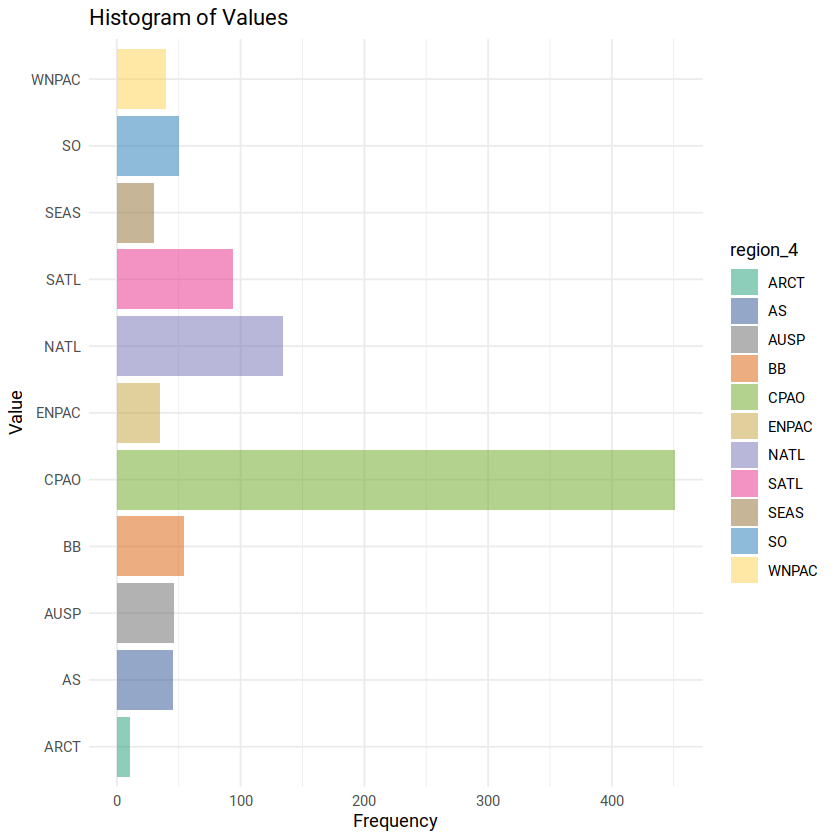

[1] 0

 ARCT    AS  AUSP    BB  CPAO ENPAC  NATL  SATL  SEAS    SO WNPAC 
   11    45    46    54   451    35   134    94    30    50    40 


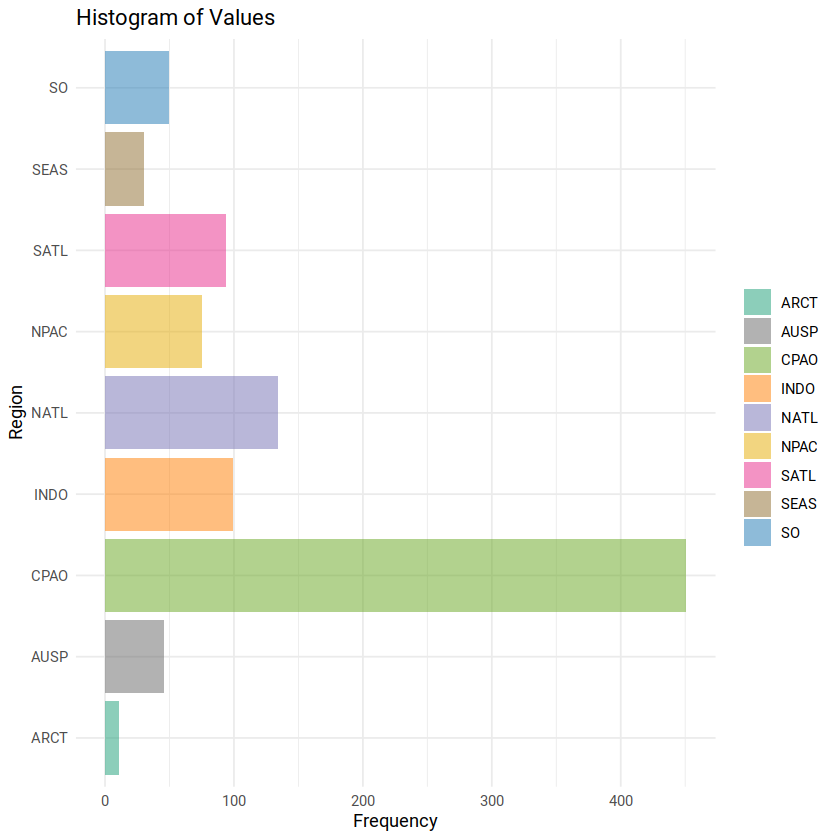

In [19]:
# Histogram of observations per each region 
ggplot(coal.ash.sims, aes(x = region_4, fill = region_4, position = "identity")) +
  geom_bar(stat = "count") +
  labs(title = "Histogram of Values", x = "Value", y = "Frequency") +
  theme_minimal() + 
  scale_fill_manual(values = India.palette) + 
  coord_flip() 

# Create a new column that combines AS and BB into INDO and E and W NPAC into NPAC
coal.ash.sims$region_4_combined <- coal.ash.sims$region_4
coal.ash.sims$region_4_combined[coal.ash.sims$region_4 %in% c("AS", "BB")] <- "INDO"
coal.ash.sims$region_4_combined[coal.ash.sims$region_4 %in% c("ENPAC", "WNPAC")] <- "NPAC"

# Create the plot
ggplot(coal.ash.sims, aes(x = region_4_combined, fill = region_4_combined)) +
  geom_bar(stat = "count", position = "stack") +
  labs(title = "Histogram of Values", x = "Region", y = "Frequency") +
  theme_minimal() + 
  scale_fill_manual(values = India.palette) +
  coord_flip() +
  theme(legend.title = element_blank())  # Optional: remove legend title

na_count <- sum(is.na(coal.ash.sims$region_4))
print(na_count)
region_counts <- table(coal.ash.sims$region_4)
print(region_counts)

In [20]:
# ------------------------------------- REGRESSION VISUALIZATIONS --------------------------------------------
# Linear Regression plots comparing obs and modeled values independent of region on a log scale 
# making single points visualized in regression for easier interpretation ------------------------------
region_count <- coal.ash.sims %>% group_by(region_4) %>% summarize(count = n())

# ADDING DETAILS FOR INDO AND NPAC COMBINED
coal.ash.sims.1 <- coal.ash.sims %>% 
  mutate(across(-c(region_4, region_4_combined), as.numeric)) %>%
  dplyr::select(-Latitude, -Longitude, -region_4_combined) %>%
  group_by(region_4) %>%
  summarize(across(everything(), median, na.rm = TRUE)) %>% 
  ungroup() %>% 
  left_join(region_count) %>% 
  mutate(count = as.numeric(count)) 

indo_row <- coal.ash.sims.1 %>%
  filter(region_4 %in% c("BB", "AS")) %>%
  dplyr::select(-matches(c("count"))) %>% 
  summarize(across(-region_4, median, na.rm = TRUE)) %>%
  mutate(region_4 = "INDO") %>% 
  mutate(Obs_solubility = Obs_sol_Fe/Obs_Fe, 
         v1_solubility = v1_sol_Fe / v1_Fe, 
         v2_solubility = v2_sol_Fe / v2_Fe, 
         v3_solubility = v3_sol_Fe / v3_Fe, 
         v4_solubility = v4_sol_Fe / v4_Fe,
         v5_solubility = v5_sol_Fe / v5_Fe,
         v6_solubility = v6_sol_Fe / v6_Fe,
         v7_solubility = v7_sol_Fe / v7_Fe,
         v8_solubility = v8_sol_Fe / v8_Fe,
        ) %>%
 mutate(count = 99)

npac_row <- coal.ash.sims.1 %>%
  filter(region_4 %in% c("ENPAC", "WNPAC")) %>%
  dplyr::select(-matches(c("count"))) %>% 
  summarize(across(-region_4, median, na.rm = TRUE)) %>%
  mutate(region_4 = "NPAC") %>% 
  mutate(Obs_solubility = Obs_sol_Fe/Obs_Fe, 
         v1_solubility = v1_sol_Fe / v1_Fe, 
         v2_solubility = v2_sol_Fe / v2_Fe, 
         v3_solubility = v3_sol_Fe / v3_Fe, 
         v4_solubility = v4_sol_Fe / v4_Fe,
         v5_solubility = v5_sol_Fe / v5_Fe,
         v6_solubility = v6_sol_Fe / v6_Fe,
         v7_solubility = v7_sol_Fe / v7_Fe,
         v8_solubility = v8_sol_Fe / v8_Fe,
        ) %>%
  mutate(count = 87)

# Add the new INDO row to the original dataset
coal.ash.sims.1 <- bind_rows(coal.ash.sims.1, indo_row, npac_row) %>% filter(region_4 != "ARCT", region_4 != "NA")

coal.ash.sims.2 <- coal.ash.sims.1 %>%
  mutate(xmin = (Obs_Fe-Obs_Fe_sd), xmax = (Obs_Fe+Obs_Fe_sd),
         ymin_v1 = (v1_Fe-v1_Fe_sd), ymax_v1 = (v1_Fe+v1_Fe_sd),
         ymin_v2 = (v2_Fe-v2_Fe_sd), ymax_v2 = (v2_Fe+v2_Fe_sd),
         ymin_v3 = (v3_Fe-v3_Fe_sd), ymax_v3 = (v3_Fe+v3_Fe_sd),
         ymin_v4 = (v5_Fe-v4_Fe_sd), ymax_v4 = (v4_Fe+v4_Fe_sd),
         ymin_v5 = (v5_Fe-v5_Fe_sd), ymax_v5 = (v5_Fe+v5_Fe_sd),
         ymin_v6 = (v6_Fe-v6_Fe_sd), ymax_v6 = (v6_Fe+v6_Fe_sd),
         ymin_v7 = (v7_Fe-v7_Fe_sd), ymax_v7 = (v7_Fe+v7_Fe_sd),
         ymin_v8 = (v8_Fe-v8_Fe_sd), ymax_v8 = (v8_Fe+v8_Fe_sd),
      
         xmin_sol = (Obs_sol_Fe-Obs_sol_Fe_sd), xmax_sol = (Obs_sol_Fe+Obs_sol_Fe_sd),
         ymin_sol_v1 = (v1_sol_Fe-v1_sol_Fe_sd), ymax_sol_v1 = (v1_sol_Fe+v1_sol_Fe_sd),
         ymin_sol_v2 = (v2_sol_Fe-v2_sol_Fe_sd), ymax_sol_v2 = (v2_sol_Fe+v2_sol_Fe_sd),
         ymin_sol_v3 = (v3_sol_Fe-v3_sol_Fe_sd), ymax_sol_v3 = (v3_sol_Fe+v3_sol_Fe_sd),
         ymin_sol_v4 = (v4_sol_Fe-v4_sol_Fe_sd), ymax_sol_v4 = (v4_sol_Fe+v4_sol_Fe_sd),
         ymin_sol_v5 = (v5_sol_Fe-v5_sol_Fe_sd), ymax_sol_v5 = (v5_sol_Fe+v5_sol_Fe_sd),
         ymin_sol_v6 = (v6_sol_Fe-v6_sol_Fe_sd), ymax_sol_v6 = (v6_sol_Fe+v6_sol_Fe_sd),
         ymin_sol_v7 = (v7_sol_Fe-v7_sol_Fe_sd), ymax_sol_v7 = (v7_sol_Fe+v7_sol_Fe_sd),
         ymin_sol_v8 = (v8_sol_Fe-v8_sol_Fe_sd), ymax_sol_v8 = (v8_sol_Fe+v8_sol_Fe_sd),
    
         xmin_solubility = (Obs_solubility-`Fe solubility_sd`), xmax_solubility = (Obs_solubility+`Fe solubility_sd`),
         ymin_solubility_v1 = (v1_solubility-v1_solubility_sd), ymax_solubility_v1 = (v1_solubility+v1_solubility_sd),
         ymin_solubility_v2 = (v2_solubility-v2_solubility_sd), ymax_solubility_v2 = (v2_solubility+v2_solubility_sd),
         ymin_solubility_v3 = (v3_solubility-v3_solubility_sd), ymax_solubility_v3 = (v3_solubility+v3_solubility_sd),
         ymin_solubility_v4 = (v4_solubility-v4_solubility_sd), ymax_solubility_v4 = (v4_solubility+v4_solubility_sd),
         ymin_solubility_v5 = (v5_solubility-v5_solubility_sd), ymax_solubility_v5 = (v5_solubility+v5_solubility_sd),
         ymin_solubility_v6 = (v6_solubility-v6_solubility_sd), ymax_solubility_v6 = (v6_solubility+v6_solubility_sd),
         ymin_solubility_v7 = (v7_solubility-v7_solubility_sd), ymax_solubility_v7 = (v7_solubility+v7_solubility_sd),
         ymin_solubility_v8 = (v8_solubility-v8_solubility_sd), ymax_solubility_v8 = (v8_solubility+v8_solubility_sd),
        ) %>% 
  mutate(across(everything(), ~ ifelse(. <= 0, 0.000001, .)))

print("done")

Joining with `by = join_by(region_4)`


[1] "done"


In [11]:
AUSP <- coal.ash.sims.2 %>% filter(region_4 == "AUSP") 

View(AUSP$xmin_sol)
View(AUSP$xmax_sol)

[1] 0.2387596

[1] 0.2392404

In [21]:
India.shapes <- c("ARCT" = 16,
                   "SO"   = 16,
                   "NATL" = 16,
                   "SATL" = 16,
                   "CPAO" = 16, 
                   "NPAC" = 16, 
                   "ENPAC" = 18,
                   "WNPAC" = 18,
                   "SEAS" = 16, 
                   "AUSP" = 16, 
                   "BB" = 18, 
                   "AS" = 18, 
                   "INDO" = 16)

Low_Shapes <- c("ARCT" = 21,
                  "SO"   = 21,
                   "SATL"   = 21,
                  "NATL" = 21,
                  "CPAO" = 21, 
                  "NPAC" = 21, 
                  "ENPAC" = 23,
                  "WNPAC" = 23,
                  "SEAS" = 21, 
                  "AUSP" = 21, 
                  "BB"   = 23,   
                  "AS"   = 23,   
                  "INDO" = 21)

High_Shapes <- c("ARCT" = 16,
                  "SO"   = 16,
                  "NATL" = 16,
                   "SATL" = 16,
                   "CPAO" = 16, 
                   "NPAC" = 16, 
                   "ENPAC" = 18,
                   "WNPAC" = 18,
                   "SEAS" = 16, 
                   "AUSP" = 16, 
                   "BB" = 18, 
                   "AS" = 18, 
                   "INDO" = 16)

India_palette <- c("ARCT" = "#1B9E7780",
                   "SO"   = "#1F78B480" ,
                   "NATL" = "#7570B380",
                   "SATL" = "#E7298A80",
                   "CPAO" = "#66A61E80" , 
                   "NPAC" = "#E6AB0280" , 
                   "ENPAC" = "#c4a13b80" ,
                   "WNPAC" = "#ffd14d80" ,
                   "SEAS" = "#8d6c2f80", 
                   "AUSP" = "#66666680", 
                   "BB" = "#D95F0280", 
                   "AS" = "#2d519280", 
                   "INDO" = "#FF7F0080")

High_palette <- c("ARCT" = "#1B9E7780",
                   "SO"   = "#1F78B480" ,
                   "NATL" = "#7570B380",
                   "SATL" = "#E7298A80",
                   "CPAO" = "#66A61E80" , 
                   "NPAC" = "#E6AB0280" , 
                   "ENPAC" = "#c4a13b80" ,
                   "WNPAC" = "#ffd14d80" ,
                   "SEAS" = "#8d6c2f80", 
                   "AUSP" = "#66666680", 
                   "BB" = "#D95F0280", 
                   "AS" = "#2d519280", 
                   "INDO" = "#FF7F0080")

Low_palette <- c("ARCT" = "#1B9E77",
                   "SO"   = "#1F78B4" ,
                   "NATL" = "#7570B3",
                   "SATL" = "#E7298A",
                   "CPAO" = "#66A61E" , 
                   "NPAC" = "#E6AB02" , 
                   "ENPAC" = "#c4a13b" ,
                   "WNPAC" = "#ffd14d" ,
                   "SEAS" = "#8d6c2f", 
                   "AUSP" = "#666666", 
                   "BB" = "#D95F02", 
                   "AS" = "#2d5192", 
                   "INDO" = "#FF7F00")

print("done")

[1] "done"


In [22]:
# Plotting functions
create_soluble_iron_plot_single_points_vHIGH <- function(data, x_var, y_var, x_min, x_max, y_min, y_max, region, color_palette, count_col, x_label = "Iron Observations (ng m-3)", y_label = "Modeled Iron (ng m-3)", plot_title = "[Soluble Iron]") {
  # Ensure count is numeric
  data[[count_col]] <- as.numeric(data[[count_col]])
  
  ggplot(data) +
    geom_abline(slope = 1, intercept = 0, color = "black", linetype = "solid", size = 1.5, show.legend = F) + 
    geom_abline(slope = 1, intercept = 1, color = "black", linetype = "dashed", size = 1, show.legend = F) +
    geom_abline(slope = 1, intercept = -1, color = "black", linetype = "dashed", size = 1, show.legend = F) +
    
    geom_errorbar(aes(x = .data[[x_var]], ymin = .data[[y_min]], ymax = .data[[y_max]]), 
                  width = 0.1, size = 1.1, alpha = 0.5, color = "gray") +
    geom_errorbar(aes(y = .data[[y_var]], xmin = .data[[x_min]], xmax = .data[[x_max]]), 
                  width = 0.1, size = 1.1, alpha = 0.5, color = "gray") +
    
    # Scatter points with dynamic aes mapping using .data[[...]] for variables
    geom_point(aes(x = .data[[x_var]], y = .data[[y_var]], 
                   color = .data[[region]], size = .data[[count_col]], 
                   shape = .data[["region_4"]],
                   stroke = 3)) +
    
    scale_color_manual(values = color_palette) +
    scale_size(range = c(4, 20)) +
    scale_shape_manual(values = India.shapes) +
    scale_x_log10(labels = scales::number_format(accuracy = 0.01)) + 
    scale_y_log10(labels = scales::number_format(accuracy = 0.01)) +
    coord_cartesian(ylim = c(0.001, 100), xlim = c(0.001, 100)) +  
    
    theme_minimal() +
    theme(legend.position = "none") +
    theme(plot.title = element_text(size = 14, face = "bold"),
          axis.title.x = element_text(size = 13, face = "bold"),
          axis.title.y = element_text(size = 13, face = "bold"),
          axis.text.x = element_text(size = 12, face = "bold"),
          axis.text.y = element_text(size = 12, face = "bold"),
 #         panel.grid.major = element_line(color = "gray97", linewidth = 0.5), # make major gridlines very faint
          panel.grid.minor = element_blank(), # Remove minor gridlines
          panel.background = element_blank()) + # remove background
    
    labs(x = x_label, y = y_label, title = plot_title) + 
    theme(
      
    )
}

create_soluble_iron_plot_single_points_vLOW <- function(data, x_var, y_var, x_min, x_max, y_min, y_max, region, color_palette, count_col, x_label = "Iron Observations (ng m-3)", y_label = "Modeled Iron (ng m-3)", plot_title = "[Soluble Iron]") {
  # Ensure count is numeric
  data[[count_col]] <- as.numeric(data[[count_col]])
  
  ggplot(data) +
    geom_abline(slope = 1, intercept = 0, color = "black", linetype = "solid", size = 1.5, show.legend = F) + 
    geom_abline(slope = 1, intercept = 1, color = "black", linetype = "dashed", size = 1, show.legend = F) +
    geom_abline(slope = 1, intercept = -1, color = "black", linetype = "dashed", size = 1, show.legend = F) +
    
    geom_errorbar(aes(x = .data[[x_var]], ymin = .data[[y_min]], ymax = .data[[y_max]]), 
                  width = 0.1, size = 1.1, alpha = 0.5, color = "gray") +
    geom_errorbar(aes(y = .data[[y_var]], xmin = .data[[x_min]], xmax = .data[[x_max]]), 
                  width = 0.1, size = 1.1, alpha = 0.5, color = "gray") +
    
    # Scatter points with dynamic aes mapping using .data[[...]] for variables
    geom_point(aes(x = .data[[x_var]], y = .data[[y_var]], 
                   color = .data[[region]], size = .data[[count_col]], 
                   shape = .data[["region_4"]],
                   stroke = 2)) + 
    
    scale_color_manual(values = color_palette) +
    scale_size(range = c(4, 20)) +
    scale_shape_manual(values = Low_Shapes) +
    scale_x_log10(labels = scales::number_format(accuracy = 0.01)) + 
    scale_y_log10(labels = scales::number_format(accuracy = 0.01)) +
    coord_cartesian(ylim = c(0.001, 100), xlim = c(0.001, 100)) +  
    
    theme_minimal() +
    theme(legend.position = "none") +
    theme(plot.title = element_text(size = 14, face = "bold"),
          axis.title.x = element_text(size = 13, face = "bold"),
          axis.title.y = element_text(size = 13, face = "bold"),
          axis.text.x = element_text(size = 12, face = "bold"),
          axis.text.y = element_text(size = 12, face = "bold"),
 #         panel.grid.major = element_line(colour = "gray90"), # make major gridlines very faint
          panel.grid.minor = element_blank(), # Remove minor gridlines
          panel.background = element_blank()) + # remove background
    
    labs(x = x_label, y = y_label, title = plot_title) + 
    theme(
      
    )
}

create_total_iron_plot_single_points_vHIGH <- function(data, x_var, y_var, x_min, x_max, y_min, y_max, region, color_palette, count_col, x_label = "Iron Observations (ng m-3)", y_label = "Modeled Iron (ng m-3)", plot_title = "[Total Iron]") {
  # Ensure count is numeric
  data[[count_col]] <- as.numeric(data[[count_col]])
  
  ggplot(data) +
    geom_abline(slope = 1, intercept = 0, color = "black", linetype = "solid", size = 1.5, show.legend = F) + 
    geom_abline(slope = 1, intercept = 1, color = "black", linetype = "dashed", size = 1, show.legend = F) +
    geom_abline(slope = 1, intercept = -1, color = "black", linetype = "dashed", size = 1, show.legend = F) +
    
    geom_errorbar(aes(x = .data[[x_var]], ymin = .data[[y_min]], ymax = .data[[y_max]]), 
                  width = 0.1, size = 1.1, alpha = 0.5, color = "gray") +
    geom_errorbar(aes(y = .data[[y_var]], xmin = .data[[x_min]], xmax = .data[[x_max]]), 
                  width = 0.1, size = 1.1, alpha = 0.5, color = "gray") +
    
    # Scatter points with dynamic aes mapping using .data[[...]] for variables
    geom_point(aes(x = .data[[x_var]], y = .data[[y_var]], 
                   color = .data[[region]], size = .data[[count_col]], 
                   shape = .data[["region_4"]],
                   stroke = 3)) + 
    
    scale_color_manual(values = color_palette) +
    scale_size(range = c(4, 20)) +
    scale_shape_manual(values = India.shapes) +
    scale_x_log10(labels = scales::number_format(accuracy = 0.01)) + 
    scale_y_log10(labels = scales::number_format(accuracy = 0.01)) +
    coord_cartesian(ylim = c(.01, 10000), xlim = c(.01, 10000)) +  
    
    theme_minimal() +
    theme(legend.position = "none") +
     theme(plot.title = element_text(size = 14, face = "bold"),
          axis.title.x = element_text(size = 13, face = "bold"),
          axis.title.y = element_text(size = 13, face = "bold"),
          axis.text.x = element_text(size = 12, face = "bold"),
          axis.text.y = element_text(size = 12, face = "bold"),
 #         panel.grid.major = element_line(color = "gray90"), # make major gridlines very faint
          panel.grid.minor = element_blank(), # Remove minor gridlines
          panel.background = element_blank()) + # remove background
      
    labs(x = x_label, y = y_label, title = plot_title)
}

create_total_iron_plot_single_points_vLOW <- function(data, x_var, y_var, x_min, x_max, y_min, y_max, region, color_palette, count_col, x_label = "Iron Observations (ng m-3)", y_label = "Modeled Iron (ng m-3)", plot_title = "[Total Iron]") {
  # Ensure count is numeric
  data[[count_col]] <- as.numeric(data[[count_col]])
  
  ggplot(data) +
    geom_abline(slope = 1, intercept = 0, color = "black", linetype = "solid", size = 1.5, show.legend = F) + 
    geom_abline(slope = 1, intercept = 1, color = "black", linetype = "dashed", size = 1, show.legend = F) +
    geom_abline(slope = 1, intercept = -1, color = "black", linetype = "dashed", size = 1, show.legend = F) +
    
    geom_errorbar(aes(x = .data[[x_var]], ymin = .data[[y_min]], ymax = .data[[y_max]]), 
                  width = 0.1, size = 1.1, alpha = 0.5, color = "gray") +
    geom_errorbar(aes(y = .data[[y_var]], xmin = .data[[x_min]], xmax = .data[[x_max]]), 
                  width = 0.1, size = 1.1, alpha = 0.5, color = "gray") +
    
    # Scatter points with dynamic aes mapping using .data[[...]] for variables
    geom_point(aes(x = .data[[x_var]], y = .data[[y_var]], 
                   color = .data[[region]], size = .data[[count_col]], 
                   shape = .data[["region_4"]],
                   stroke = 2)) + 
    
    scale_color_manual(values = color_palette) +
    scale_size(range = c(4, 20)) +
    scale_shape_manual(values = Low_Shapes) +
    scale_x_log10(labels = scales::number_format(accuracy = 0.01)) + 
    scale_y_log10(labels = scales::number_format(accuracy = 0.01)) +
    coord_cartesian(ylim = c(.01, 10000), xlim = c(.01, 10000)) +  
    
    theme_minimal() +
    theme(legend.position = "none") +
    theme(plot.title = element_text(size = 14, face = "bold"),
          axis.title.x = element_text(size = 13, face = "bold"),
          axis.title.y = element_text(size = 13, face = "bold"),
          axis.text.x = element_text(size = 12, face = "bold"),
          axis.text.y = element_text(size = 12, face = "bold"),
 #         panel.grid.major = element_line(color = "gray90"), # make major gridlines very faint
          panel.grid.minor = element_blank(), # Remove minor gridlines
          panel.background = element_blank()) + # remove background
    
    labs(x = x_label, y = y_label, title = plot_title)
}

create_solubility_plot_single_points_vHIGH <- function(data, x_var, y_var, x_min, x_max, y_min, y_max, region, color_palette, count_col,
                                                    x_label = "Iron Observations (%)", y_label = "Modeled Fe (%)", plot_title = "Iron Solubility") {
  # Ensure count is numeric
  data[[count_col]] <- as.numeric(data[[count_col]])
  
  ggplot(data) +
    geom_abline(slope = 1, intercept = 0, color = "black", linetype = "solid", size = 1.5, show.legend = F) + 
    geom_abline(slope = 1, intercept = 1, color = "black", linetype = "dashed", size = 1, show.legend = F) +
    geom_abline(slope = 1, intercept = -1, color = "black", linetype = "dashed", size = 1, show.legend = F) +
    
    geom_errorbar(aes(x = .data[[x_var]], ymin = .data[[y_min]], ymax = .data[[y_max]]), 
                  width = 0.1, size = 1.1, alpha = 0.5, color = "gray") +
    geom_errorbar(aes(y = .data[[y_var]], xmin = .data[[x_min]], xmax = .data[[x_max]]), 
                  width = 0.1, size = 1.1, alpha = 0.5, color = "gray") +
    
    # Scatter points with dynamic aes mapping using .data[[...]] for variables
    geom_point(aes(x = .data[[x_var]], y = .data[[y_var]], 
                   color = .data[[region]], size = .data[[count_col]], 
                   shape = .data[["region_4"]],
                   stroke = 3)) + 
    
    scale_color_manual(values = color_palette) +
    scale_size(range = c(4, 20)) +
    scale_shape_manual(values = India.shapes) +
    scale_x_log10(labels = scales::number_format(accuracy = 0.01)) + 
    scale_y_log10(labels = scales::number_format(accuracy = 0.01)) +
    coord_cartesian(ylim = c(0.001, .2), xlim = c(0.001, .2)) +  
    
    theme_minimal() +
    theme(legend.position = "none") +
    theme(plot.title = element_text(size = 14, face = "bold"),
          axis.title.x = element_text(size = 13, face = "bold"),
          axis.title.y = element_text(size = 13, face = "bold"),
          axis.text.x = element_text(size = 12, face = "bold"),
          axis.text.y = element_text(size = 12, face = "bold"),
 #         panel.grid.major = element_line(color = "gray90"), # make major gridlines very faint
          panel.grid.minor = element_blank(), # Remove minor gridlines
          panel.background = element_blank()) + # remove background
    
    labs(x = x_label, y = y_label, title = plot_title)
}

create_solubility_plot_single_points_vLOW <- function(data, x_var, y_var, x_min, x_max, y_min, y_max, region, color_palette, count_col,
                                                    x_label = "Iron Observations (%)", y_label = "Modeled Fe (%)", plot_title = "Iron Solubility") {
  # Ensure count is numeric
  data[[count_col]] <- as.numeric(data[[count_col]])
  
  ggplot(data) +
    geom_abline(slope = 1, intercept = 0, color = "black", linetype = "solid", size = 1.5, show.legend = F) + 
    geom_abline(slope = 1, intercept = 1, color = "black", linetype = "dashed", size = 1, show.legend = F) +
    geom_abline(slope = 1, intercept = -1, color = "black", linetype = "dashed", size = 1, show.legend = F) +
    
    geom_errorbar(aes(x = .data[[x_var]], ymin = .data[[y_min]], ymax = .data[[y_max]]), 
                  width = 0.1, size = 1.1, alpha = 0.5, color = "gray") +
    geom_errorbar(aes(y = .data[[y_var]], xmin = .data[[x_min]], xmax = .data[[x_max]]), 
                  width = 0.1, size = 1.1, alpha = 0.5, color = "gray") +
    
    # Scatter points with dynamic aes mapping using .data[[...]] for variables
    geom_point(aes(x = .data[[x_var]], y = .data[[y_var]], 
                   color = .data[[region]], size = .data[[count_col]], 
                   shape = .data[["region_4"]],
                   stroke = 2 )) + 
    
    scale_color_manual(values = color_palette) +
    scale_size(range = c(4, 20)) +
    scale_shape_manual(values = Low_Shapes) +
    scale_x_log10(labels = scales::number_format(accuracy = 0.01)) + 
    scale_y_log10(labels = scales::number_format(accuracy = 0.01)) +
    coord_cartesian(ylim = c(0.001, .2), xlim = c(0.001, .2)) +  
    
    theme_minimal() +
    theme(legend.position = "none") +
     theme(plot.title = element_text(size = 14, face = "bold"),
          axis.title.x = element_text(size = 13, face = "bold"),
          axis.title.y = element_text(size = 13, face = "bold"),
          axis.text.x = element_text(size = 12, face = "bold"),
          axis.text.y = element_text(size = 12, face = "bold"),
#          panel.grid.major = element_line(color = "gray90"), # make major gridlines very faint
          panel.grid.minor = element_blank(), # Remove minor gridlines
          panel.background = element_blank()) + # remove background
    
    labs(x = x_label, y = y_label, title = plot_title)
}

print("done")


[1] "done"


In [23]:
# list out the following (df, "x_var", "y_var", "x_min", "x_max", "y_min", "y_max", region, color_palette, "count")
v1.dot.plot.sol <- create_soluble_iron_plot_single_points_vHIGH(coal.ash.sims.2, "Obs_sol_Fe", "v1_sol_Fe", "xmin_sol", "xmax_sol", "ymin_sol_v1", "ymax_sol_v1", "region_4", India.palette, "count")
v1.dot.plot.tot <- create_total_iron_plot_single_points_vHIGH(coal.ash.sims.2, "Obs_Fe", "v1_Fe", "xmin", "xmax", "ymin_v1", "ymax_v1", "region_4", India.palette,  "count")
v1.dot.plot.per.sol <- create_solubility_plot_single_points_vHIGH(coal.ash.sims.2, "Obs_solubility", "v1_solubility", "xmin_solubility", "xmax_solubility", "ymin_solubility_v1", "ymax_solubility_v1", "region_4", India.palette, "count")

v2.dot.plot.sol <- create_soluble_iron_plot_single_points_vHIGH(coal.ash.sims.2, "Obs_sol_Fe", "v2_sol_Fe", "xmin_sol", "xmax_sol", "ymin_sol_v2", "ymax_sol_v2", "region_4", India.palette, "count")
v2.dot.plot.per.sol <- create_solubility_plot_single_points_vHIGH(coal.ash.sims.2, "Obs_solubility", "v2_solubility", "xmin_solubility", "xmax_solubility", "ymin_solubility_v2", "ymax_solubility_v2", "region_4", India.palette, "count")

v3.dot.plot.sol <- create_soluble_iron_plot_single_points_vHIGH(coal.ash.sims.2, "Obs_sol_Fe", "v3_sol_Fe", "xmin_sol", "xmax_sol", "ymin_sol_v3", "ymax_sol_v3", "region_4", India.palette, "count")
v3.dot.plot.per.sol <- create_solubility_plot_single_points_vHIGH(coal.ash.sims.2, "Obs_solubility", "v3_solubility", "xmin_solubility", "xmax_solubility", "ymin_solubility_v3", "ymax_solubility_v3", "region_4", India.palette, "count")

v4.dot.plot.sol <- create_soluble_iron_plot_single_points_vHIGH(coal.ash.sims.2, "Obs_sol_Fe", "v4_sol_Fe", "xmin_sol", "xmax_sol", "ymin_sol_v4", "ymax_sol_v4", "region_4", India.palette, "count")
v4.dot.plot.per.sol <- create_solubility_plot_single_points_vHIGH(coal.ash.sims.2, "Obs_solubility", "v4_solubility", "xmin_solubility", "xmax_solubility", "ymin_solubility_v4", "ymax_solubility_v4", "region_4", India.palette, "count")

v5.dot.plot.sol <- create_soluble_iron_plot_single_points_vLOW(coal.ash.sims.2, "Obs_sol_Fe", "v5_sol_Fe", "xmin_sol", "xmax_sol", "ymin_sol_v5", "ymax_sol_v5", "region_4", Low_palette, "count")
v5.dot.plot.per.sol <- create_solubility_plot_single_points_vLOW(coal.ash.sims.2, "Obs_solubility", "v5_solubility", "xmin_solubility", "xmax_solubility", "ymin_solubility_v5", "ymax_solubility_v5", "region_4", Low_palette, "count")
v5.dot.plot.tot <- create_total_iron_plot_single_points_vLOW(coal.ash.sims.2, "Obs_Fe", "v5_Fe", "xmin", "xmax", "ymin_v5", "ymax_v5", "region_4", Low_palette,  "count")

v6.dot.plot.sol <- create_soluble_iron_plot_single_points_vLOW(coal.ash.sims.2, "Obs_sol_Fe", "v6_sol_Fe", "xmin_sol", "xmax_sol", "ymin_sol_v6", "ymax_sol_v6", "region_4", Low_palette, "count")
v6.dot.plot.per.sol <- create_solubility_plot_single_points_vLOW(coal.ash.sims.2, "Obs_solubility", "v6_solubility", "xmin_solubility", "xmax_solubility", "ymin_solubility_v6", "ymax_solubility_v6", "region_4", Low_palette, "count")

v7.dot.plot.sol <- create_soluble_iron_plot_single_points_vLOW(coal.ash.sims.2, "Obs_sol_Fe", "v7_sol_Fe", "xmin_sol", "xmax_sol", "ymin_sol_v7", "ymax_sol_v7", "region_4", Low_palette, "count")
v7.dot.plot.per.sol <- create_solubility_plot_single_points_vLOW(coal.ash.sims.2, "Obs_solubility", "v7_solubility", "xmin_solubility", "xmax_solubility", "ymin_solubility_v7", "ymax_solubility_v7", "region_4", Low_palette, "count")

v8.dot.plot.sol <- create_soluble_iron_plot_single_points_vLOW(coal.ash.sims.2, "Obs_sol_Fe", "v8_sol_Fe", "xmin_sol", "xmax_sol", "ymin_sol_v8", "ymax_sol_v8", "region_4", Low_palette, "count")
v8.dot.plot.per.sol <- create_solubility_plot_single_points_vLOW(coal.ash.sims.2, "Obs_solubility", "v8_solubility", "xmin_solubility", "xmax_solubility", "ymin_solubility_v8", "ymax_solubility_v8", "region_4", Low_palette, "count")
print("done")

[1] "done"


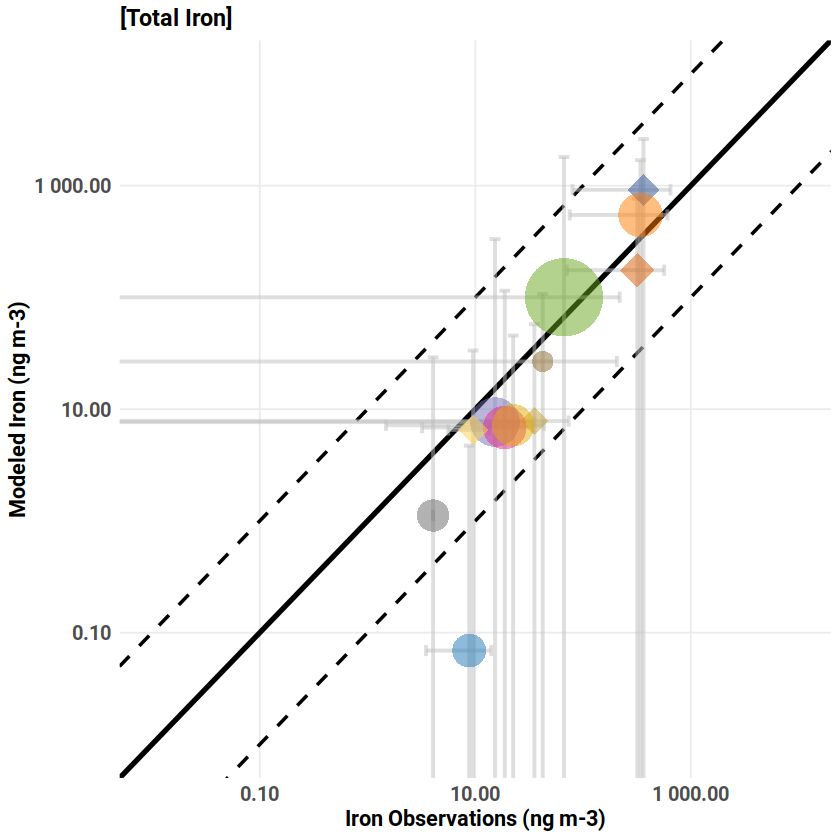

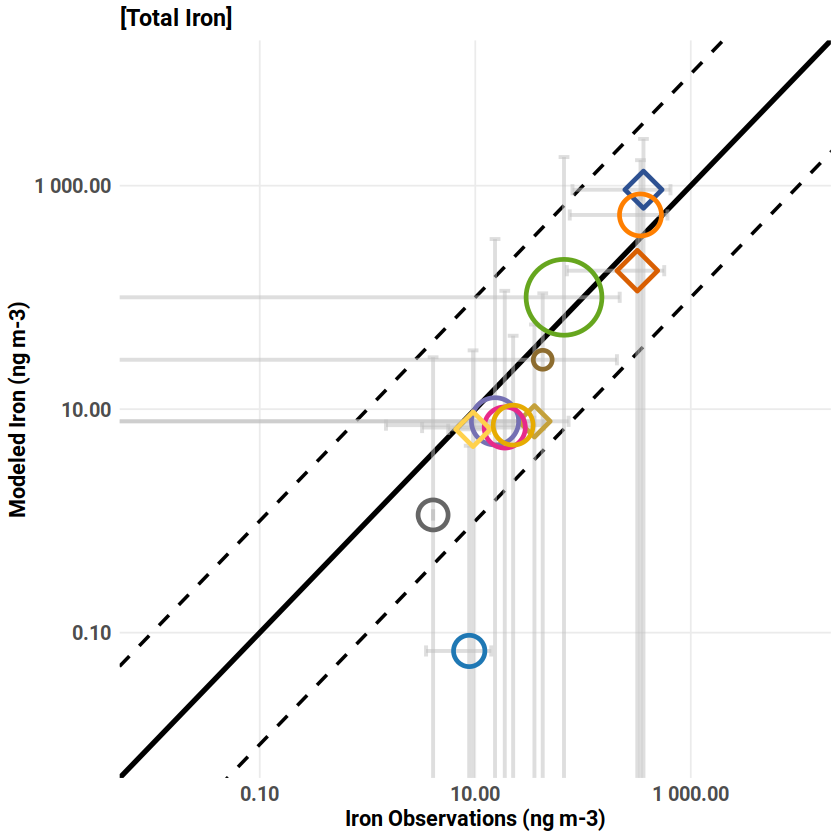

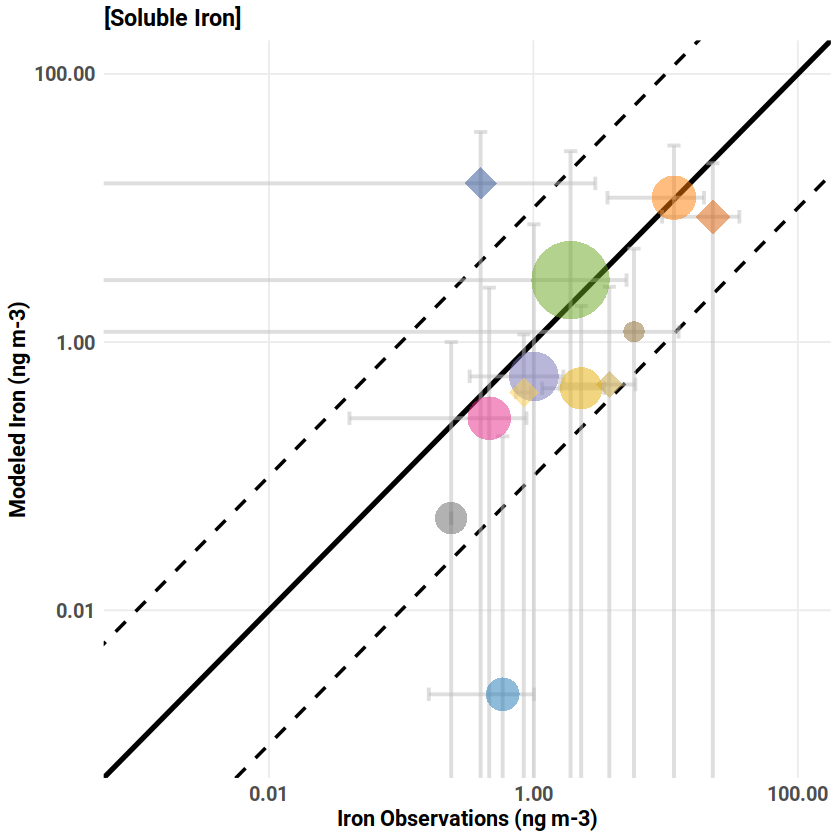

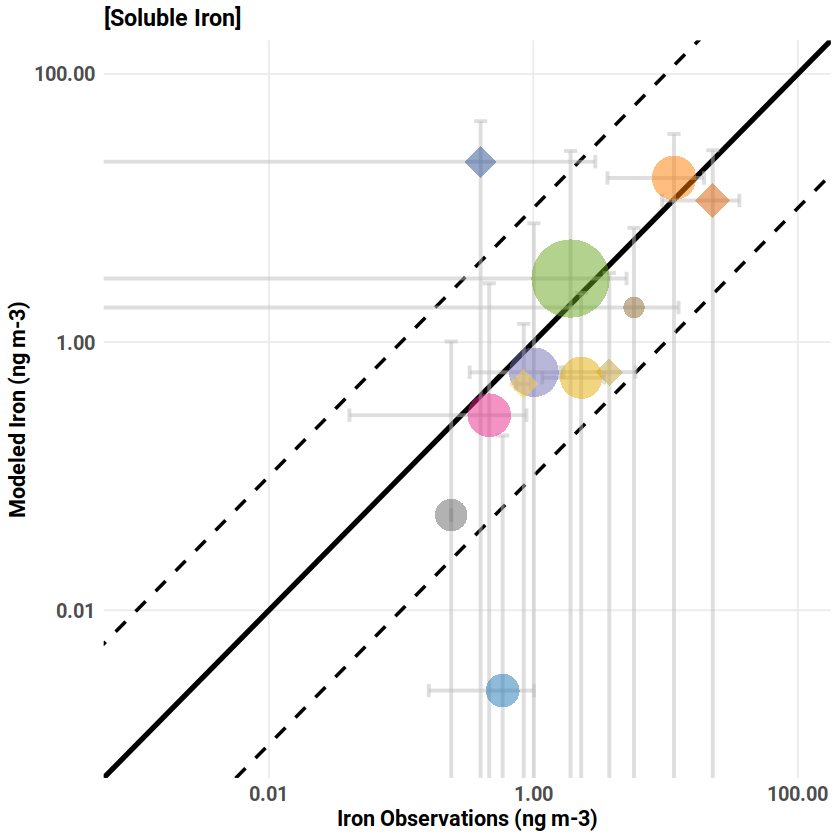

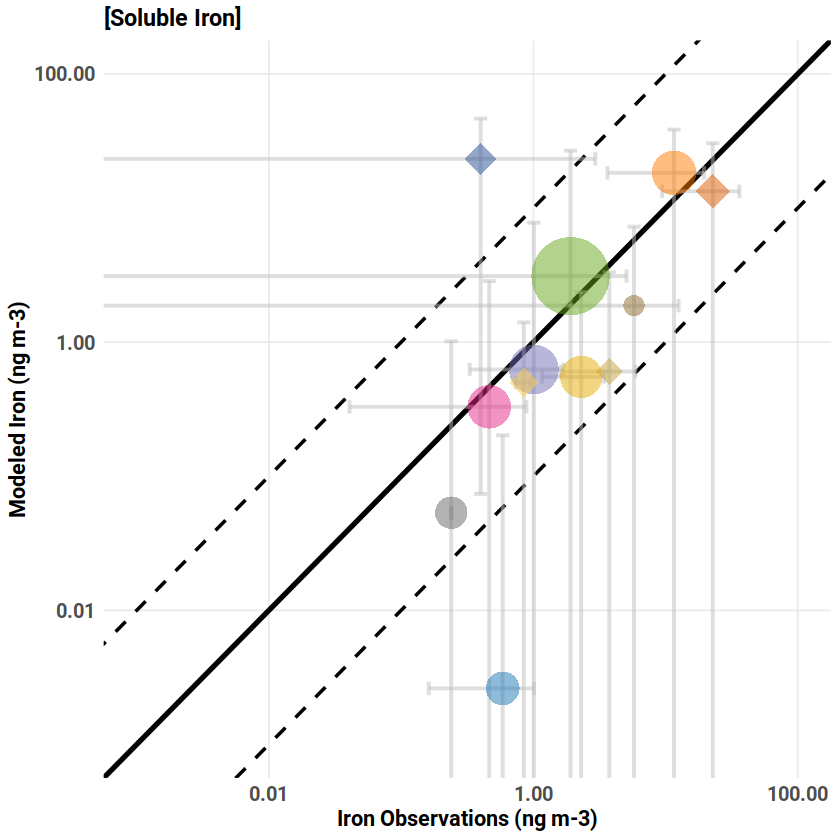

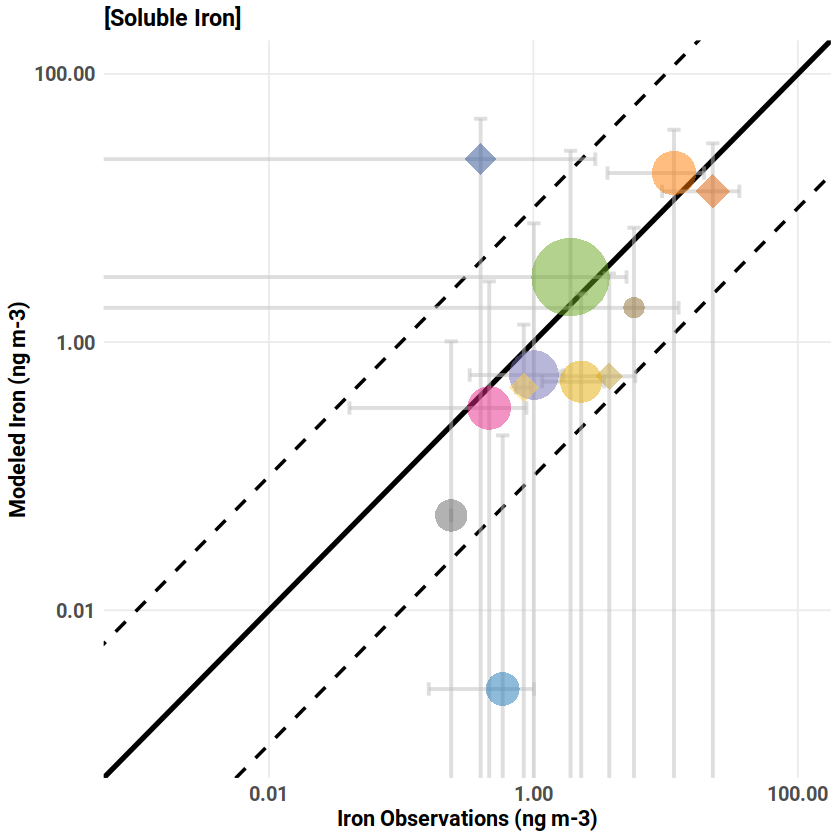

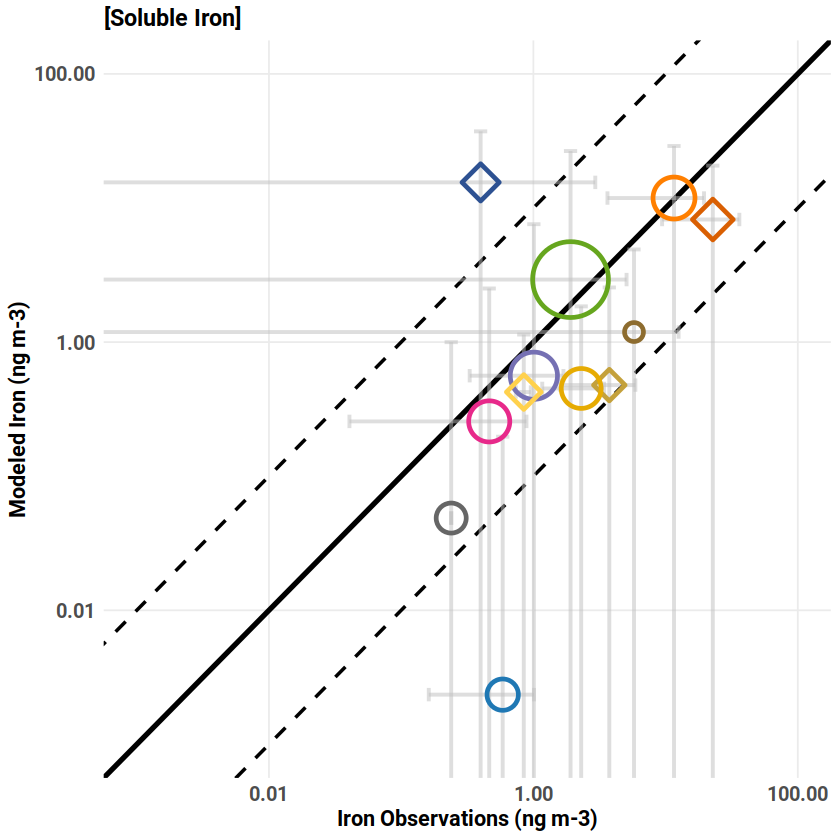

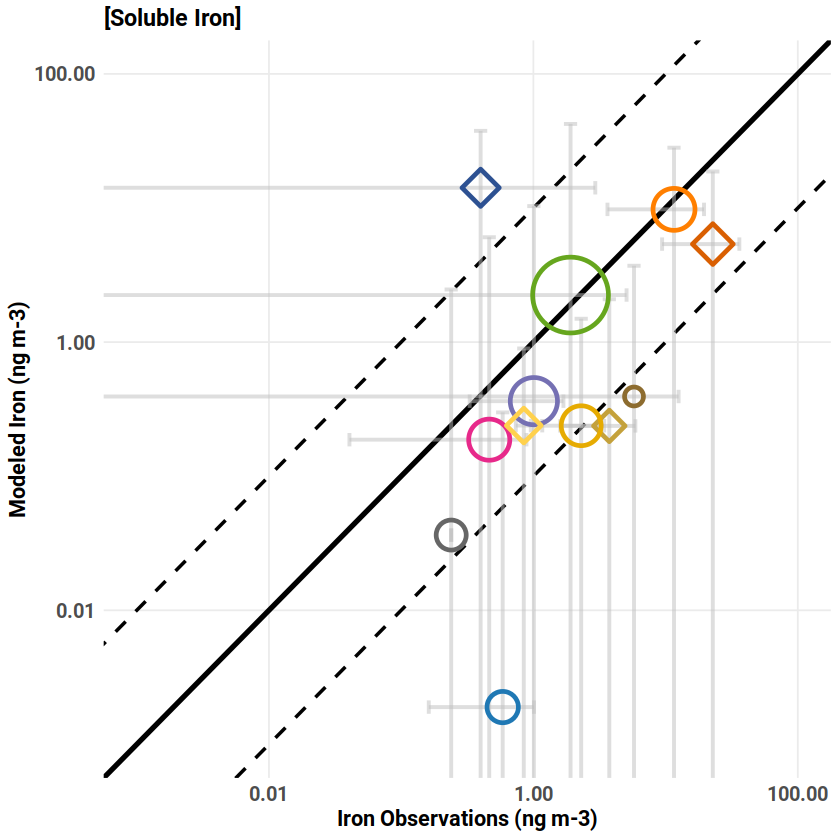

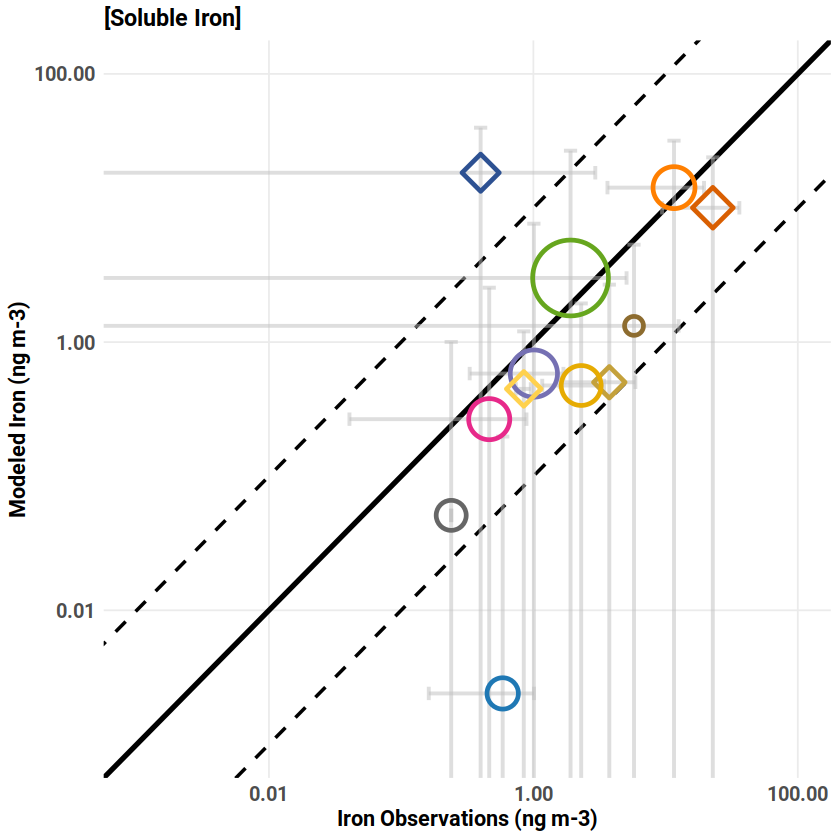

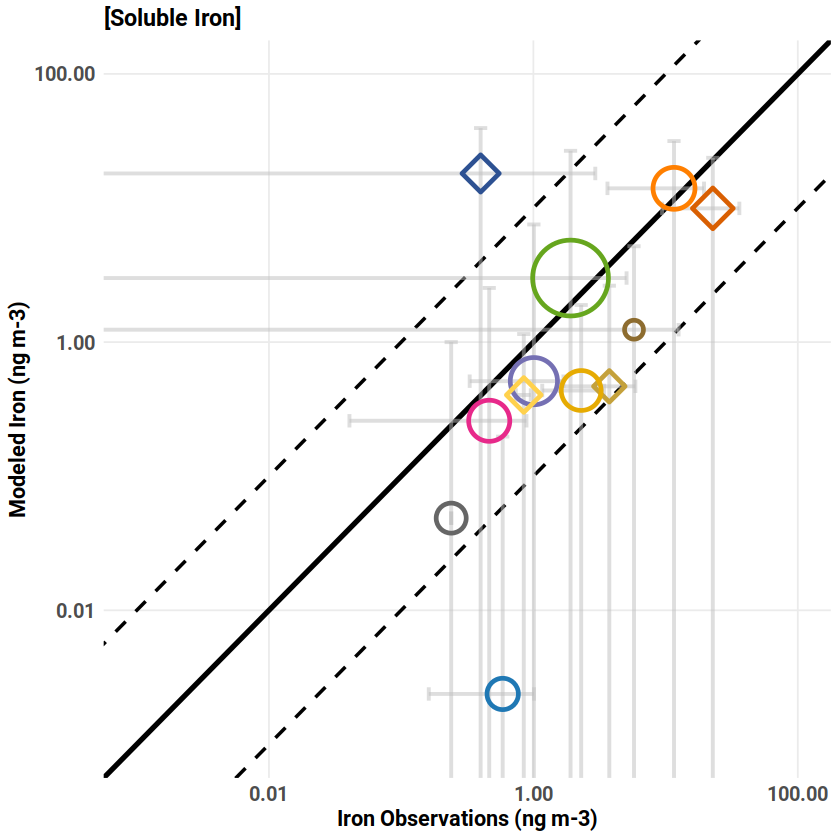

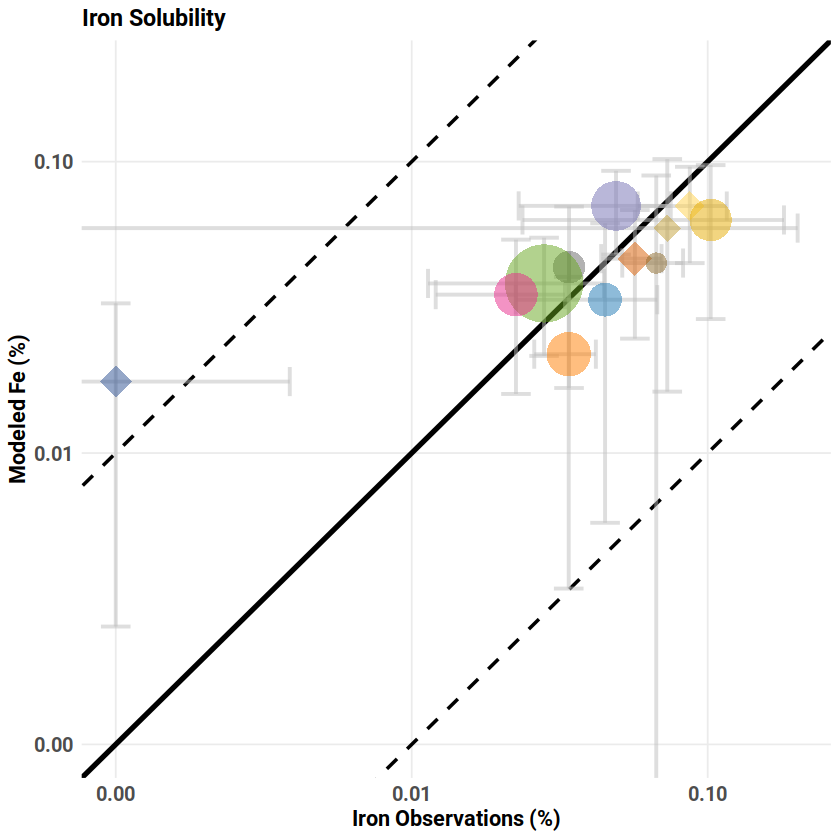

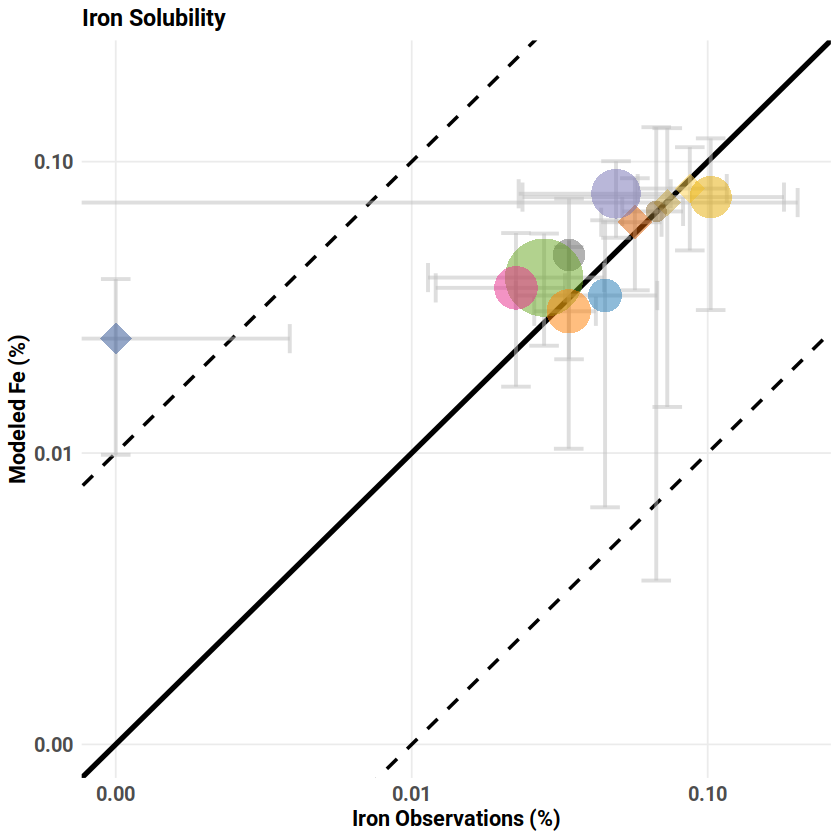

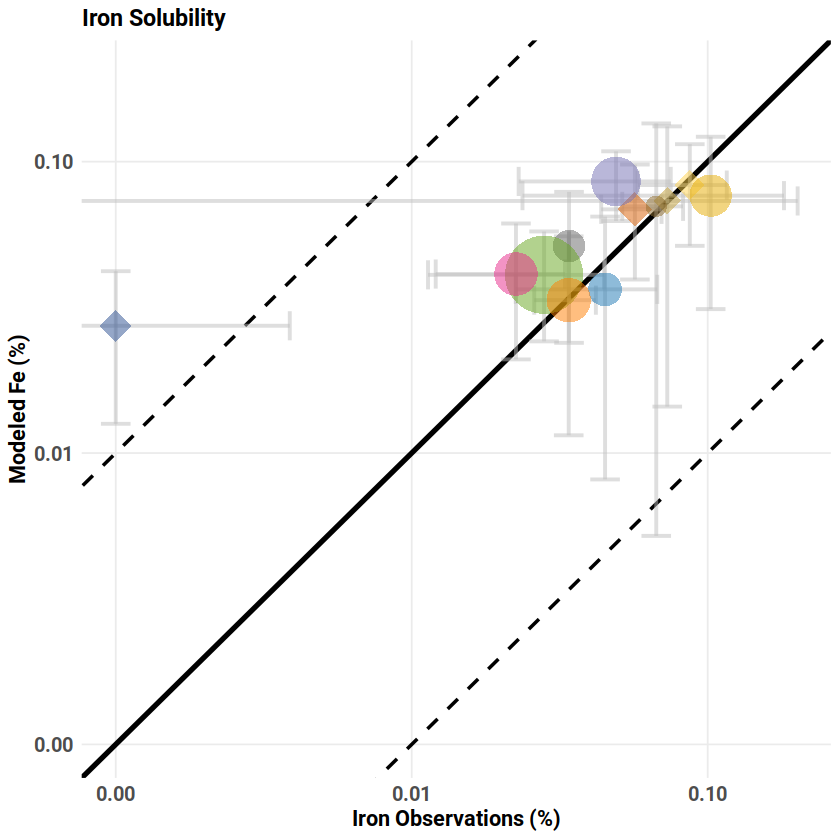

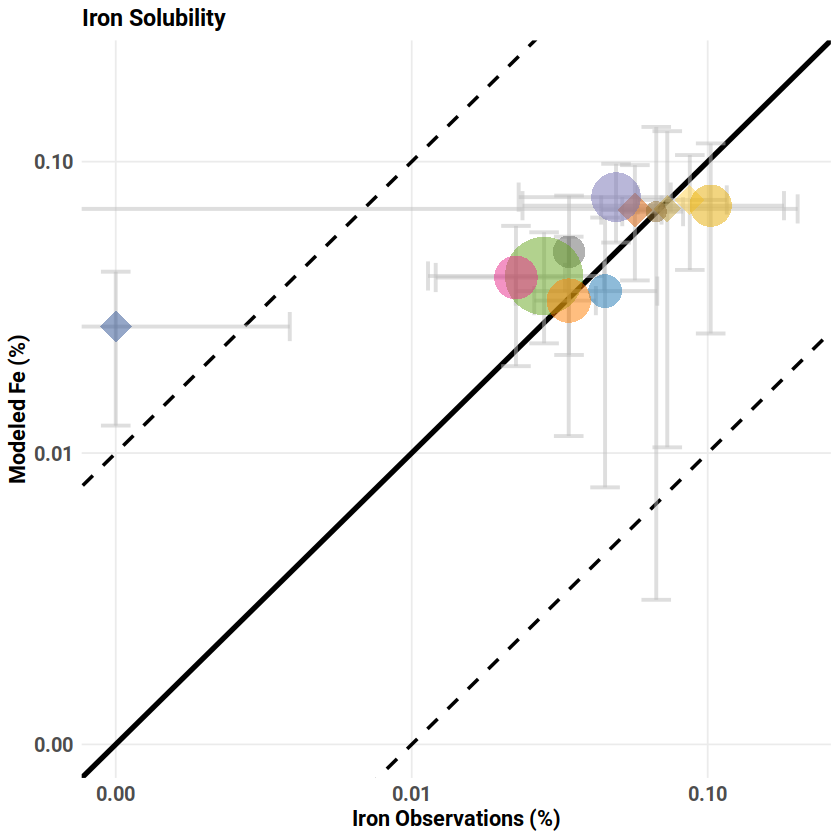

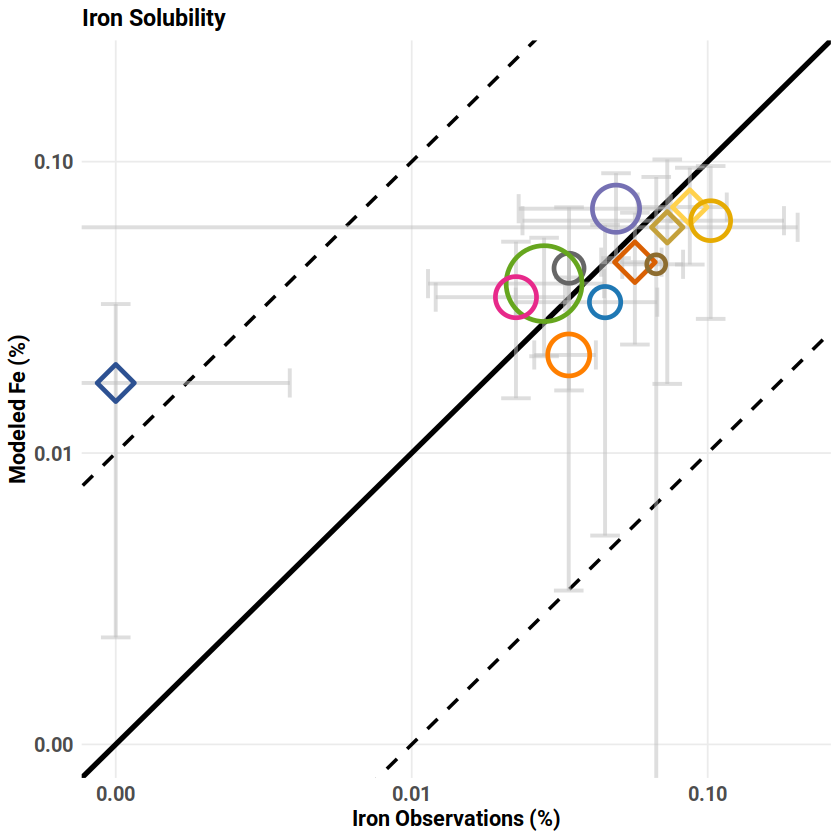

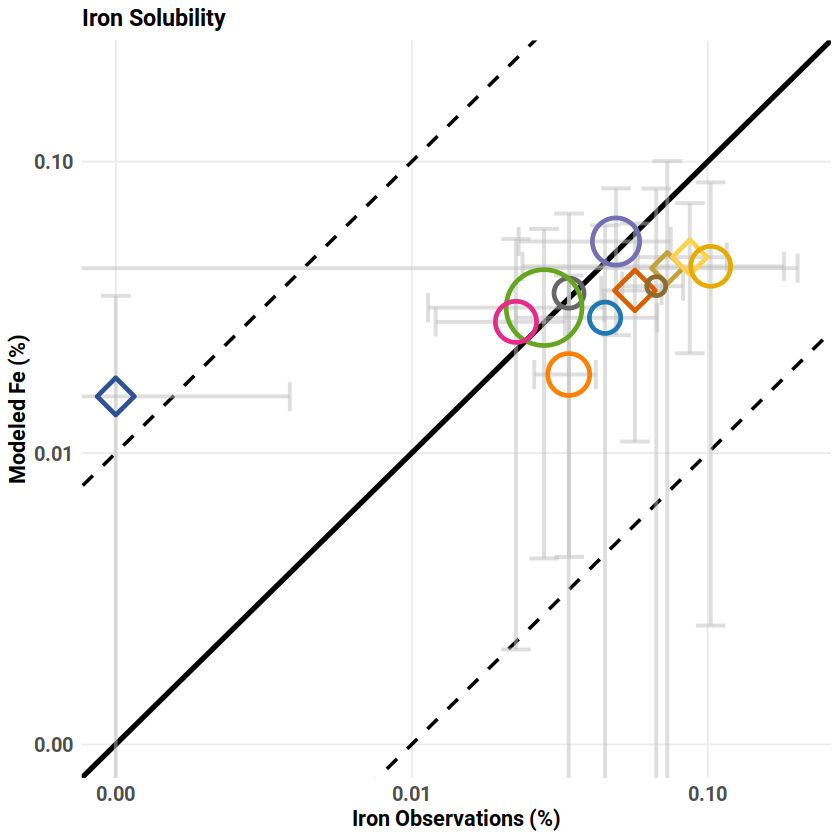

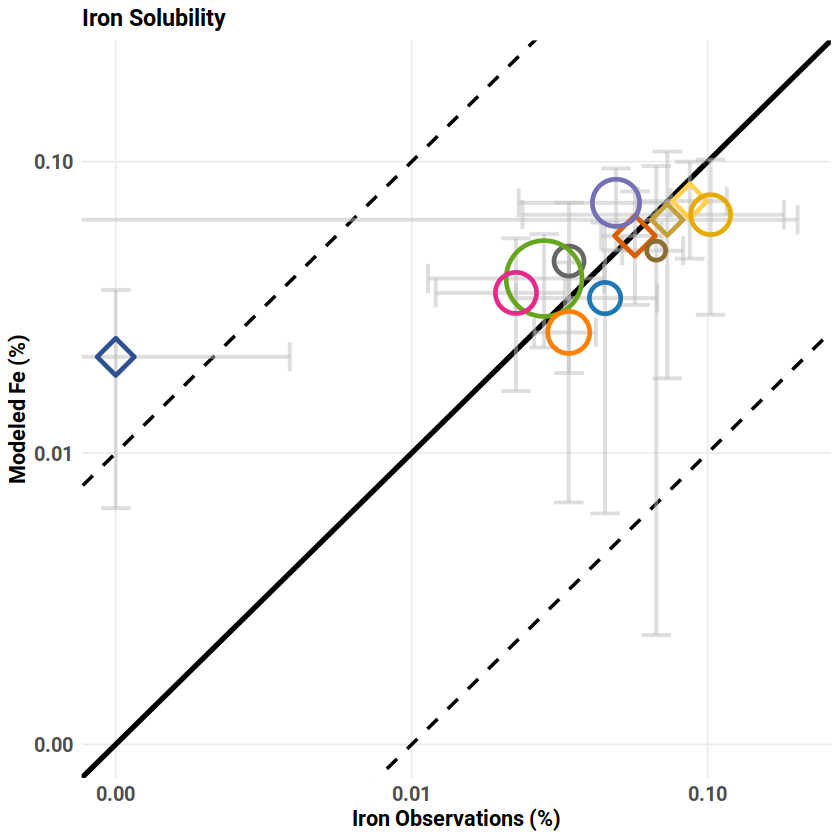

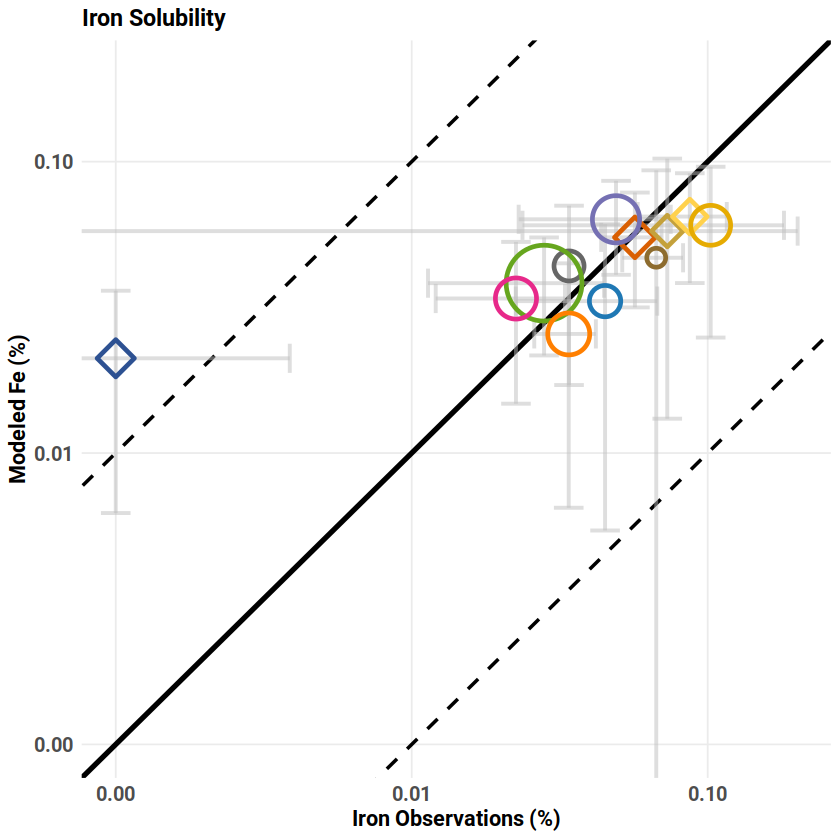

In [24]:
# SAVING THE PLOTS THEMSELVES -------------------
# FINAL CHECK PASSED -- CAN RECREATE FIGURES
# NOW JUST NEED TO SUB IN FINAL PLOT ONCE MODEL V3 LOW RESIDENTIAL EMISSIONS IS DONE 
save_directory <- "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/Plots/regressions/"
v1.dot.plot.tot
ggsave(paste0(save_directory, "v1.dot.plot.tot.pdf"), plot = v1.dot.plot.tot, bg = "transparent", width = 7, height = 7, dpi = 300)
v5.dot.plot.tot
ggsave(paste0(save_directory, "v5.dot.plot.tot.pdf"), plot = v5.dot.plot.tot, bg = "transparent", width = 7, height = 7, dpi = 300)

v1.dot.plot.sol 
ggsave(paste0(save_directory, "v1.dot.plot.sol.pdf"), plot = v1.dot.plot.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v2.dot.plot.sol 
ggsave(paste0(save_directory, "v2.dot.plot.sol.pdf"), plot = v2.dot.plot.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v3.dot.plot.sol
ggsave(paste0(save_directory, "v3.dot.plot.sol.pdf"), plot = v3.dot.plot.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v4.dot.plot.sol
ggsave(paste0(save_directory, "v4.dot.plot.sol.pdf"), plot = v4.dot.plot.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v5.dot.plot.sol
ggsave(paste0(save_directory, "v5.dot.plot.sol.pdf"), plot = v5.dot.plot.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v6.dot.plot.sol
ggsave(paste0(save_directory, "v6.dot.plot.sol.pdf"), plot = v6.dot.plot.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v7.dot.plot.sol
ggsave(paste0(save_directory, "v7.dot.plot.sol.pdf"), plot = v7.dot.plot.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v8.dot.plot.sol
ggsave(paste0(save_directory, "v8.dot.plot.sol.pdf"), plot = v8.dot.plot.sol, bg = "transparent", width = 7, height = 7, dpi = 300)

v1.dot.plot.per.sol
ggsave(paste0(save_directory, "v1.dot.plot.per.sol.pdf"), plot = v1.dot.plot.per.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v2.dot.plot.per.sol
ggsave(paste0(save_directory, "v2.dot.plot.per.sol.pdf"), plot = v2.dot.plot.per.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v3.dot.plot.per.sol 
ggsave(paste0(save_directory, "v3.dot.plot.per.sol.pdf"), plot = v3.dot.plot.per.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v4.dot.plot.per.sol
ggsave(paste0(save_directory, "v4.dot.plot.per.sol.pdf"), plot = v4.dot.plot.per.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v5.dot.plot.per.sol
ggsave(paste0(save_directory, "v5.dot.plot.per.sol.pdf"), plot = v5.dot.plot.per.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v6.dot.plot.per.sol
ggsave(paste0(save_directory, "v6.dot.plot.per.sol.pdf"), plot = v6.dot.plot.per.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v7.dot.plot.per.sol
ggsave(paste0(save_directory, "v7.dot.plot.per.sol.pdf"), plot = v7.dot.plot.per.sol, bg = "transparent", width = 7, height = 7, dpi = 300)
v8.dot.plot.per.sol
ggsave(paste0(save_directory, "v8.dot.plot.per.sol.pdf"), plot = v8.dot.plot.per.sol, bg = "transparent", width = 7, height = 7, dpi = 300)